# **9. Spatio-Temporal Graph Neural Network (STGNN)**

El modelo Spatio-Temporal Graph Neural Network (STGNN) es una arquitectura de aprendizaje profundo diseñada específicamente para el modelado espacio-temporal del dengue a nivel departamental. Su propósito principal es capturar la compleja dinámica de transmisión de la enfermedad mediante la representación explícita de las relaciones geográficas entre departamentos como un grafo, permitiendo que la información epidemiológica y climática fluya no solo a través del tiempo, sino también a través del espacio.

```text
         [ Input Tensor: (B, T, N, Features) ]
                          |
          +---------------+---------------+
          |                               |
  [ Epi Features ]               [ Clim Features ]
          |                               |
  Node Feature Embedding         Node Feature Embedding
          |                               |
          +---------------+---------------+
                          |
              [ Graph Construction ]
              Adjacency Matrix A(N x N)
          (contigüidad geográfica / distancia)
                          |
                 [ Spatial Module ]
            Graph Convolutional Network (GCN)
          Propagación de señal entre nodos vecinos
                          |
                 [ Temporal Module ]
           Gated Recurrent Unit (GRU) / TCN
         Captura de dependencias secuenciales
                          |
                 [ ST-Block × L capas ]
            (Spatial → Temporal apilados)
                          |
                  Readout & Pooling
                          |
                 Dropout & FC Layer
                          |
          [ Output: Horizon Predictions (B, H, N) ]
```

La arquitectura del modelo procesa los datos a través de cuatro componentes fundamentales. Primero, el **Node Feature Embedding** proyecta las variables epidemiológicas y climáticas de cada departamento a un espacio de representación común ($d_{\text{model}}$), tratando cada unidad geográfica como un nodo del grafo con su propio vector de características. Después, el **Graph Construction Module** construye la matriz de adyacencia $A \in \mathbb{R}^{N \times N}$ que codifica las relaciones espaciales entre departamentos, ya sea por contigüidad geográfica, distancia geodésica o conectividad ponderada por flujos de movilidad poblacional. Luego, el **ST-Block** apila sucesivamente una capa espacial —una Graph Convolutional Network (GCN) que propaga y agrega señales entre nodos vecinos mediante $H^{(l+1)} = \sigma(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}H^{(l)}W^{(l)})$— y una capa temporal que captura las dependencias secuenciales a lo largo de la ventana histórica—, repitiéndose $L$ veces para aprender representaciones espacio-temporales de creciente abstracción. Finalmente, la **Capa de Salida** aplica una operación de *readout* sobre los nodos y mapea la representación aprendida mediante una capa lineal (`nn.Linear`) para predecir la incidencia del dengue a un horizonte de cuatro semanas por departamento.

## **9.1. Librerías**

In [1]:
import os, copy, random, warnings, math, sys, time
import optuna
import shap
import numpy as np
import pandas as pd
import scipy.stats as st
import geopandas as gpd
from scipy.spatial.distance import cdist

from spatialkfold.clusters import spatial_kfold_clusters
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **9.2. Configuración & Reproducibilidad**

Se establece el entorno y las configuraciones de reproducibilidad del proyecto, inicializando las semillas globales (`SEEDS`), el número de pliegues espaciales (`N_SPATIAL_FOLDS = 5`) y los intentos de optimización con Optuna.

In [2]:
SEEDS           = [42, 123, 2024]
N_SPATIAL_FOLDS = 5
N_OPTUNA_TRIALS = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("medium")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Python:", sys.version)
print("Torch:",  torch.__version__)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"  Seed fijada: {seed}")

g = torch.Generator()

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
Torch: 2.12.0.dev20260407+cu128


## **9.3. Carga de Datos & Feature Engineering**

Se inicializan las rutas del proyecto y se carga el conjunto de datos principal (`df_full.csv`), indexando la columna temporal en formato `datetime` para posteriormente ordenar de forma ascendente los registros por departamento y fecha, asegurando así la consistencia cronológica necesaria para el análisis de las series de tiempo.

In [9]:
from pathlib import Path

BASE_PATH = Path("/home/moon/DEEP/PF/PF_DG/MODELOS/STGNN_CV")
BASE_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("/home/moon/DEEP/PF/PF_DG/DATA/Bases_Datos/df_full.csv")
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])
df = df.sort_values(["departamento", "fecha_inicio"]).reset_index(drop=True)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 21664 | Columnas: 54


,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


Se realiza la ingeniería de características mapeando cíclicamente las semanas epidemiológicas mediante funciones seno y coseno para capturar la estacionalidad del dengue, definimos los conjuntos de variables predictoras epidemiológicas y climáticas con sus respectivos rezagos históricos, y aplicamos una transformación logarítmica (`log1p`) sobre la incidencia para mitigar el sesgo provocado por los picos extremos de los brotes.

In [5]:
df["semana"] = df["semana"].astype(int)
df["ano"]    = df["fecha_inicio"].dt.year

weeks_per_year  = df.groupby("ano")["semana"].transform("max")
df["week_norm"] = df["semana"] / weeks_per_year
df["week_sin"]  = np.sin(2 * np.pi * df["week_norm"])
df["week_cos"]  = np.cos(2 * np.pi * df["week_norm"])

EPIFEATURES = [
    "inc_lag_1","inc_lag_2","inc_lag_3","inc_lag_4",
    "inc_lag_8","inc_lag_12","inc_lag_20",
    "poblacion","prop_rural","week_sin","week_cos"
]
CLIMFEATURES = [
    "temp_lag_1","temp_lag_2","temp_lag_4","temp_lag_8","temp_lag_12","temp_lag_20",
    "humedad_lag_1","humedad_lag_2","humedad_lag_4","humedad_lag_8","humedad_lag_12","humedad_lag_20",
    "precip_lag_1","precip_lag_2","precip_lag_4","precip_lag_8","precip_lag_12","precip_lag_20",
]
FEATURES = EPIFEATURES + CLIMFEATURES

df["incidencia_log"] = np.log1p(df["incidencia"])
TARGET = "incidencia_log"
N_EPI  = len(EPIFEATURES)
N_CLIM = len(CLIMFEATURES)

print(f"EpiFeatures : {N_EPI}")
print(f"ClimFeatures: {N_CLIM}")
print(f"Total       : {len(FEATURES)} | Target: {TARGET}")

EpiFeatures : 11
ClimFeatures: 18
Total       : 29 | Target: incidencia_log


In [6]:
departments = sorted(df["departamento"].unique())
dept_to_idx = {d: i for i, d in enumerate(departments)}
idx_to_dept = {i: d for d, i in dept_to_idx.items()}
NUM_NODES   = len(departments)
print(f"NUM_NODES: {NUM_NODES}")
print("Departamentos:", departments)

NUM_NODES: 32
Departamentos: ['Amazonas', 'Antioquia', 'Arauca', 'Atlantico', 'Bogota d.c.', 'Bolivar', 'Boyaca', 'Caldas', 'Caqueta', 'Casanare', 'Cauca', 'Cesar', 'Choco', 'Cordoba', 'Cundinamarca', 'Guainia', 'Guajira', 'Guaviare', 'Huila', 'Magdalena', 'Meta', 'Narino', 'Norte De Santander', 'Putumayo', 'Quindio', 'Risaralda', 'Santander', 'Sucre', 'Tolima', 'Valle Del Cauca', 'Vaupes', 'Vichada']


## **9.4. Construcción de Folds Espaciales y Matriz de Adyacencia del Grafo**

### **9.4.1 Folds espaciales**

Se estructura la partición geográfica del modelo construyendo un objeto `GeoDataFrame` a partir de los centroides calculados para cada departamento, el cual se proyecta a coordenadas UTM para evitar las distorsiones métricas del sistema de grados cartesianos. Posteriormente, se aplica la función `spatial_kfold_clusters` mediante un algoritmo de KMeans para agrupar los territorios en cinco pliegues espaciales contiguos, mapeando estas asignaciones de vuelta al conjunto de datos principal y generando una visualización cartográfica que valida la distribución regional y previene la fuga de información por proximidad geográfica durante la validación cruzada.

In [12]:
cent = pd.read_csv("/home/moon/DEEP/PF/PF_DG/DATA/Covariables/centroides_departamentos.csv")

dept_coords = (
    cent.groupby("departamento")
      .agg(lat=("latitud", "mean"), lon=("longitud", "mean"))
      .reset_index()
)

geometry      = gpd.points_from_xy(dept_coords["lon"], dept_coords["lat"])
gdf_depts     = gpd.GeoDataFrame(dept_coords, geometry=geometry, crs="EPSG:4326")
gdf_depts_utm = gdf_depts.to_crs(gdf_depts.estimate_utm_crs())

In [ ]:
gdf_depts_folded = spatial_kfold_clusters(
    gdf=gdf_depts_utm,
    name="departamento",
    nfolds=N_SPATIAL_FOLDS,
    algorithm="kmeans",
    random_state=42
)
print("Columnas resultado:", gdf_depts_folded.columns.tolist())
print(gdf_depts_folded[["departamento","folds"]].sort_values("folds").to_string(index=False))

Columnas resultado: ['departamento', 'lat', 'lon', 'geometry', 'folds']
      departamento  folds
         Atlantico      1
           Bolivar      1
           Cordoba      1
             Cesar      1
             Sucre      1
Norte De Santander      1
         Magdalena      1
           Guajira      1
           Caqueta      2
             Huila      2
            Narino      2
          Putumayo      2
             Cauca      2
      Cundinamarca      3
       Bogota d.c.      3
         Antioquia      3
            Tolima      3
           Quindio      3
         Risaralda      3
         Santander      3
            Boyaca      3
            Caldas      3
             Choco      3
              Meta      3
   Valle Del Cauca      3
          Guaviare      4
            Vaupes      4
          Amazonas      4
           Guainia      5
          Casanare      5
            Arauca      5
           Vichada      5


In [ ]:
fold_map = gdf_depts_folded.set_index("departamento")["folds"].to_dict()
df["spatial_fold"] = df["departamento"].map(fold_map)

print("Observaciones por fold espacial:")
print(df.groupby("spatial_fold")["departamento"].nunique().rename("n_departamentos"))
print("\nDepartamentos por fold:")
for fold_id, grp in df.groupby("spatial_fold")["departamento"].unique().items():
    print(f"  Fold {fold_id}: {sorted(grp)}")

Observaciones por fold espacial:
spatial_fold
1     8
2     5
3    12
4     3
5     4
Name: n_departamentos, dtype: int64

Departamentos por fold:
  Fold 1: ['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', 'Guajira', 'Magdalena', 'Norte De Santander', 'Sucre']
  Fold 2: ['Caqueta', 'Cauca', 'Huila', 'Narino', 'Putumayo']
  Fold 3: ['Antioquia', 'Bogota d.c.', 'Boyaca', 'Caldas', 'Choco', 'Cundinamarca', 'Meta', 'Quindio', 'Risaralda', 'Santander', 'Tolima', 'Valle Del Cauca']
  Fold 4: ['Amazonas', 'Guaviare', 'Vaupes']
  Fold 5: ['Arauca', 'Casanare', 'Guainia', 'Vichada']


### **9.4.2 Matriz de adyacencia del grafo espacial**

Se construye la matriz de adyacencia del grafo espacial que conecta los departamentos según proximidad geográfica, aplicando un kernel gaussiano sobre las distancias en kilómetros para asignar pesos continuos a los $k=5$ vecinos más cercanos de cada nodo y normalizando simétricamente el resultado como $\hat{A} = D^{-1/2}AD^{-1/2}$. Finalmente, convierte esta matriz en un tensor de PyTorch listo para el entrenamiento y genera dos visualizaciones diagnósticas: el mapa de calor de pesos normalizados y la distribución geográfica de los folds espaciales por *K-Means*.

In [ ]:
def build_adjacency_matrix(dept_list, dept_coords_df, k_neighbors=5, sigma_km=200.0):

    coords = dept_coords_df.set_index("departamento").loc[dept_list, ["lat","lon"]].values
    dist_km = cdist(coords, coords) * 111.0

    N = len(dept_list)
    A = np.zeros((N, N), dtype=np.float32)

    for i in range(N):
        row_dists = dist_km[i].copy()
        row_dists[i] = np.inf                        
        nn_idx = np.argsort(row_dists)[:k_neighbors]
        for j in nn_idx:
            if sigma_km is not None:
                w = np.exp(-(dist_km[i, j] ** 2) / (2 * sigma_km ** 2))
            else:
                w = 1.0
            A[i, j] = w
            A[j, i] = w                               

    np.fill_diagonal(A, 1.0)

    D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1) + 1e-10))
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt

    return A_hat.astype(np.float32), A.astype(np.float32)


A_hat_full, A_bin_full = build_adjacency_matrix(
    dept_list=departments,
    dept_coords_df=dept_coords,
    k_neighbors=5,
    sigma_km=200.0
)

print(f"A_hat_full shape: {A_hat_full.shape}")
print(f"Densidad del grafo: {(A_bin_full > 0).mean():.3f}")
print(f"Grado promedio (sin self-loops): {(A_bin_full > 0).sum(axis=1).mean() - 1:.1f} vecinos")

A_HAT_TENSOR = torch.tensor(A_hat_full, dtype=torch.float32)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(A_hat_full, ax=axes[0], cmap="Blues",
            xticklabels=departments, yticklabels=departments,
            cbar_kws={"label": "Peso normalizado"})
axes[0].set_title("Matriz de adyacencia normalizada A_hat", fontweight="bold")
axes[0].tick_params(axis="x", rotation=90, labelsize=6)
axes[0].tick_params(axis="y", rotation=0,  labelsize=6)

axes[1].imshow(A_bin_full, cmap="Blues", aspect="auto")
axes[1].set_title("Grafo binario (k=5 vecinos)", fontweight="bold")
axes[1].set_xticks(range(NUM_NODES)); axes[1].set_xticklabels(departments, rotation=90, fontsize=6)
axes[1].set_yticks(range(NUM_NODES)); axes[1].set_yticklabels(departments, fontsize=6)

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_adjacency_matrix.png", dpi=150)
plt.show()

A_hat_full shape: (32, 32)
Densidad del grafo: 0.232
Grado promedio (sin self-loops): 6.4 vecinos


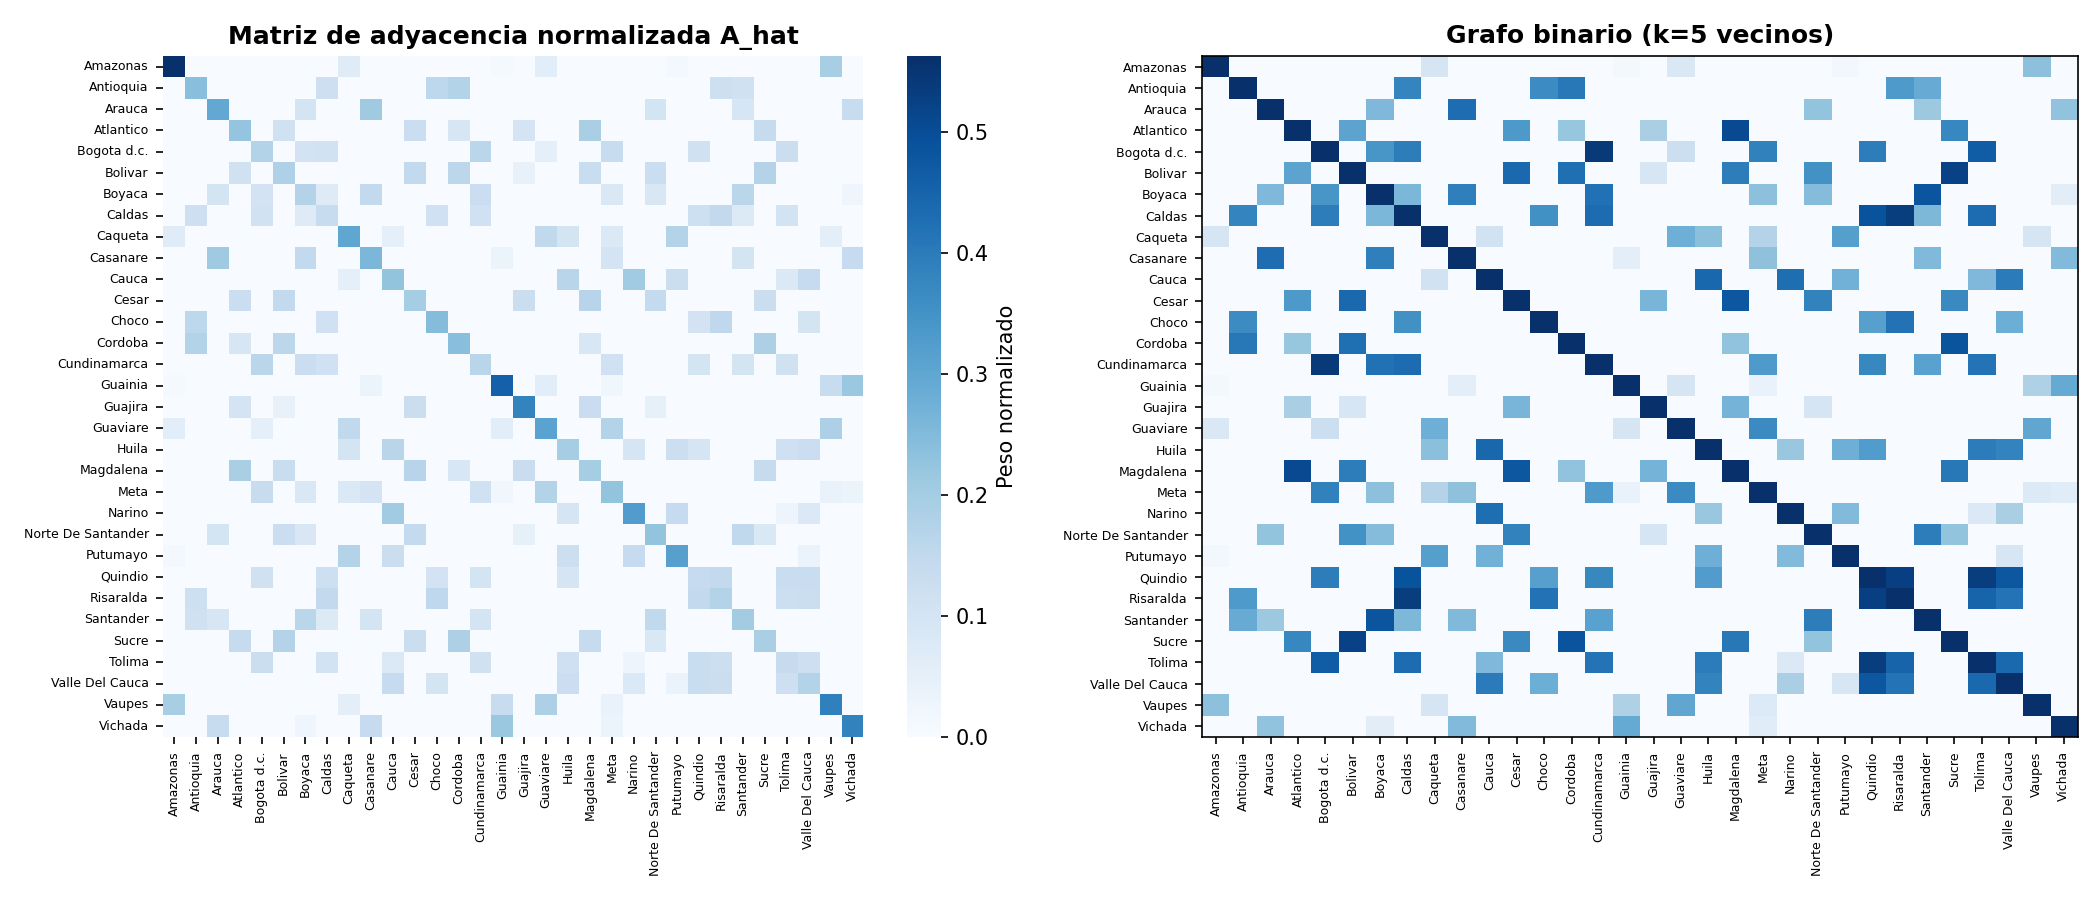

In [10]:
from PIL import Image
Image.open(f"{BASE_PATH}/stgnn_adjacency_matrix.png")

Las visualizaciones de la matriz de adyacencia confirman las propiedades estructurales del grafo espacial construido para el STGNN. La **matriz normalizada $\hat{A}$** exhibe una estructura predominantemente diagonal con valores de peso concentrados en la diagonal principal —self-loops con peso 1.0 antes de la normalización— y conexiones de intensidad decreciente hacia los $k=5$ vecinos más cercanos de cada nodo; los bloques de mayor densidad fuera de la diagonal corresponden a clústeres geográficos reconocibles: el grupo Cundinamarca–Bogotá–Boyacá en el eje andino central, el grupo Guajira–Guaviare en la región nororiental, y el grupo Vaupés–Vichada en la Amazonia oriental. El **grafo binario** ($k=5$ vecinos) hace explícita la topología de conectividad: departamentos con posición geográfica central como Boyacá, Cundinamarca y Santander presentan patrones de conexión más distribuidos —conectados tanto con vecinos andinos como con departamentos del Caribe y los Llanos—, mientras que departamentos periféricos como Amazonas, Vaupés y Vichada concentran sus conexiones en un subconjunto reducido de vecinos geográficamente próximos, resultando en nodos de menor grado efectivo en el grafo. La presencia de celdas oscuras en la esquina inferior derecha —Vaupés, Vichada— y superior izquierda —Amazonas— refleja la conectividad entre departamentos amazónicos y llaneros que comparten frontera geográfica pero están distantes del resto del sistema, formando un subgrafo periférico con escasa integración al eje central de transmisión epidémica del país.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 9))
for fold_id in range(N_SPATIAL_FOLDS):
    sub = gdf_depts_folded[gdf_depts_folded["folds"] == fold_id]
    sub.plot(ax=ax, markersize=120, label=f"Fold {fold_id}")
    for _, row in sub.iterrows():
        ax.annotate(row["departamento"], xy=(row.geometry.x, row.geometry.y),
                    fontsize=5, ha="center", va="bottom")
ax.set_title(f"Folds espaciales KMeans (k={N_SPATIAL_FOLDS})", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_spatial_folds_map.png", dpi=150)
plt.show()

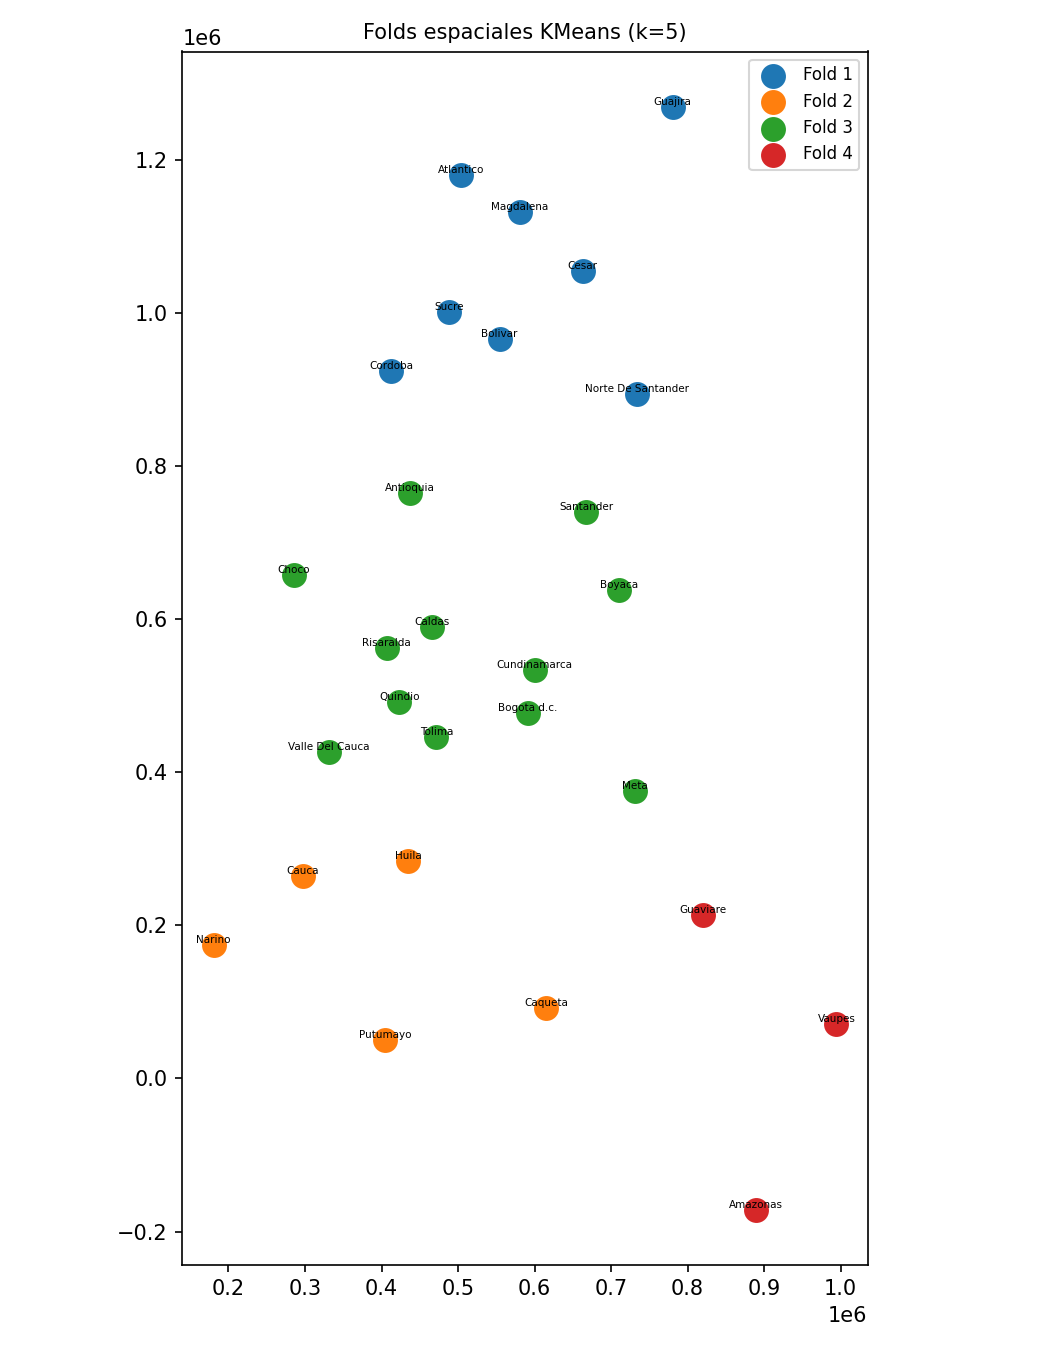

In [11]:
from PIL import Image
Image.open(f"{BASE_PATH}/stgnn_spatial_folds_map.png")

El mapa de folds espaciales KMeans ($k=5$) ilustra la partición geográfica de los departamentos utilizada en la validación cruzada espacial. El **Fold 1** (azul) agrupa los departamentos de la región Caribe y norte del país —Atlántico, Magdalena, Cesar, Sucre, Bolívar, Córdoba, Guajira y Norte de Santander—, conformando un clúster geográficamente cohesivo de alta densidad poblacional y transmisión endémica de dengue en la franja costera norte. El **Fold 2** (naranja) reúne departamentos del suroccidente y sur del país —Cauca, Huila, Nariño, Caquetá y Putumayo—, caracterizados por su posición periférica, relieve montañoso y dinámica epidémica particular influenciada por factores ambientales del Pacífico y la Amazonia occidental. El **Fold 3** (verde) es el más heterogéneo del conjunto, abarcando el eje andino central y oriental —Antioquia, Chocó, Caldas, Risaralda, Quindío, Tolima, Valle del Cauca, Cundinamarca, Bogotá d.c., Boyacá, Santander y Meta—, que concentra la mayor parte de la población urbana del país y los departamentos de mayor incidencia acumulada histórica. El **Fold 4** (rojo) agrupa los departamentos amazónicos de menor densidad poblacional y mayor aislamiento geográfico —Amazonas, Vaupés y Guaviare—, que presentan las dinámicas epidémicas más irregulares y variables del sistema. La distribución espacial de los folds refleja que el algoritmo KMeans captura patrones geográficos interpretables —regiones naturales y corredores de transmisión— que corresponden a unidades epidemiológicas funcionalmente diferenciadas, validando la idoneidad de esta partición para evaluar la generalización espacial de los modelos.

## **9.5. Esquema de Validación Espacio-Temporal**

Esta sección define la estrategia de validación cruzada anidada (*Nested Cross-Validation*) para evaluar el modelo bajo un enfoque espacio-temporal estricto y robusto. Mediante las funciones `create_outer_folds` y `create_inner_folds`, el código fragmenta cronológicamente los datos en bloques externos de prueba (años 2022 a 2024) y bloques internos de validación (años 2019 a 2021) para simular escenarios reales de predicción a futuro. Finalmente, integra el estimador `LeaveOneGroupOut` de scikit-learn, configurando un esquema donde cada ciclo de optimización (*tuning*) cruza estas ventanas de tiempo con las regiones geográficas previas, garantizando que el algoritmo sea evaluado aislando grupos espaciales completos para medir su capacidad de generalización en territorios no observados.

In [ ]:
def create_outer_folds(df, date_col="fecha_inicio"):
    folds = []
    for test_year in [2022, 2023, 2024]:
        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()
        folds.append({"test_year": test_year, "train_df": train_df, "test_df": test_df})
    return folds

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):
    inner_folds = []
    for val_year in val_years:
        inner_train = train_df[train_df["fecha_inicio"].dt.year <  val_year].copy()
        inner_val   = train_df[train_df["fecha_inicio"].dt.year == val_year].copy()
        inner_folds.append({"val_year": val_year,
                             "inner_train": inner_train,
                             "inner_val":   inner_val})
    return inner_folds

outer_folds = create_outer_folds(df)
LOGO = LeaveOneGroupOut()

print(f"Outer folds temporales: {len(outer_folds)}")
print(f"Inner folds temporales: 3 (2019, 2020, 2021)")
print(f"Folds espaciales: {N_SPATIAL_FOLDS}")
print(f"Total iteraciones tuning por trial: {3 * N_SPATIAL_FOLDS}")

Outer folds temporales: 3
Inner folds temporales: 3 (2019, 2020, 2021)
Folds espaciales: 5
Total iteraciones tuning por trial: 15


## **9.6. Ventanas de Tiempo & Escalamiento**

Se reestructuran los datos en ventanas deslizantes tridimensionales y posteriormente se realiza una normalización estadística. La función `create_windows` utiliza tablas de pivote para transformar el DataFrame plano en tensores organizados por tiempo, nodos (departamentos) y características, generando secuencias históricas de entrenamiento (`window_size=12`) emparejadas con sus respectivos horizontes de predicción futura (`horizon=4`). Por otro lado, la función `scale_data` implementa un objeto `RobustScaler` que se ajusta exclusivamente con los datos de entrenamiento tras aplanar temporalmente las dimensiones, escalando las señales basándose en percentiles e rangos intercuartílicos para neutralizar el impacto de valores atípicos extremos antes de devolver los arreglos con su forma espacio-temporal original.

In [ ]:
def create_windows(df, features, target, window_size=12, horizon=4):
    pivot_features = []
    for feat in features:
        pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                               values=feat).sort_index()
        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)   # (T, nodes, n_features)

    target_pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                                  values=target).sort_index()
    y_all  = target_pivot.values
    dates  = target_pivot.index.values

    X, y, base_dates = [], [], []
    for i in range(len(dates) - window_size - horizon + 1):
        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(base_dates)

def scale_data(X_train, X_val):
    scaler = RobustScaler()
    nf     = X_train.shape[-1]
    X_train_2d = X_train.reshape(-1, nf)
    scaler.fit(X_train_2d)
    X_train_sc = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val_sc   = scaler.transform(X_val.reshape(-1, nf)).reshape(X_val.shape)
    return X_train_sc, X_val_sc, scaler

def subgraph_adjacency(dept_subset, all_depts, A_hat_all):

    idx = [all_depts.index(d) for d in sorted(dept_subset)]
    A_sub = A_hat_all[np.ix_(idx, idx)]

    D_inv_sqrt = np.diag(1.0 / np.sqrt(A_sub.sum(axis=1) + 1e-10))
    A_sub_norm = (D_inv_sqrt @ A_sub @ D_inv_sqrt).astype(np.float32)
    return A_sub_norm

## **9.7. Dataset, Early Stopping & Funciones de Entrenamiento**

Se define la infraestructura de entrenamiento del STGNN mediante cuatro componentes: `STGNNDataset` encapsula los tensores de entrada y salida en un objeto compatible con `DataLoader`; `EarlyStopping` monitorea la pérdida de validación y detiene el entrenamiento si no mejora tras `patience=20` épocas consecutivas para prevenir sobreajuste; `train_one_epoch` ejecuta una época completa de optimización con propagación hacia atrás y recorte de gradientes (`clip_grad_norm_`) para estabilizar el aprendizaje; y `validate_one_epoch` evalúa el modelo en modo inferencia sin actualizar pesos, retornando la pérdida promedio sobre el conjunto de validación.

In [ ]:
class STGNNDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class EarlyStopping:
    def __init__(self, patience=20):
        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False
    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

def train_one_epoch(model, dataloader, criterion, optimizer,
                    device, n_epi, n_clim, A_tensor):
    model.train()
    total_loss = 0
    A = A_tensor.to(device)
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        pred, _ = model(X_batch, A, n_epi, n_clim)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate_one_epoch(model, dataloader, criterion, device, n_epi, n_clim, A_tensor):
    model.eval()
    total_loss = 0
    A = A_tensor.to(device)
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            pred, _ = model(X_batch, A, n_epi, n_clim)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(dataloader)

## **9.8. Métricas**

Se consolida el módulo de evaluación estadística del proyecto sobre los arreglos aplanados de los valores reales y predichos. Más allá de los indicadores tradicionales de magnitud de error como RMSE y MAE, se integra coeficientes hidrológicos y ecológicos avanzados como la eficiencia de Nash-Sutcliffe (`nse`) y el índice de Kling-Gupta (`kge`) para diagnosticar sesgos estructurales y variabilidad en la serie de tiempo. Asimismo, incorpora métricas de estricto control epidemiológico como el `rmse_top10`, el cual aísla los registros que superan el percentil 90 con el fin de cuantificar de forma específica el desempeño del modelo frente a picos extremos y brotes epidémicos severos de dengue.

In [ ]:
def mape(y_true, y_pred, eps=1.0):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def smape(y_true, y_pred, eps=1.0):
    num = np.abs(y_true - y_pred)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + eps
    return np.mean(num / den) * 100

def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-10)

def kge(y_true, y_pred):
    r     = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-10)
    beta  = np.mean(y_pred) / (np.mean(y_true) + 1e-10)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def skill_score(y_true, y_pred):
    mse_model = mean_squared_error(y_true, y_pred)
    mse_naive = mean_squared_error(y_true, np.full_like(y_true, np.mean(y_true)))
    return 1 - mse_model / (mse_naive + 1e-10)

def rmse_top10(y_true, y_pred, q=0.90):
    threshold = np.quantile(y_true, q)
    mask = y_true >= threshold
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def pearson_r(y_true, y_pred):
    if np.std(y_true) < 1e-10 or np.std(y_pred) < 1e-10:
        return np.nan
    return np.corrcoef(y_true, y_pred)[0, 1]

def compute_all_metrics(y_true, y_pred, prefix=""):
    yt, yp = np.array(y_true).flatten(), np.array(y_pred).flatten()
    return {
        f"{prefix}RMSE":       np.sqrt(mean_squared_error(yt, yp)),
        f"{prefix}MAE":        mean_absolute_error(yt, yp),
        f"{prefix}MAPE":       mape(yt, yp),
        f"{prefix}sMAPE":      smape(yt, yp),
        f"{prefix}NSE":        nse(yt, yp),
        f"{prefix}KGE":        kge(yt, yp),
        f"{prefix}SkillScore": skill_score(yt, yp),
        f"{prefix}RMSE_top10": rmse_top10(yt, yp),
        f"{prefix}Pearson_r":  pearson_r(yt, yp),
        f"{prefix}Bias":       float(np.mean(yp - yt)),
    }

print("Metricas cargadas.")

Metricas cargadas.


## **9.9. Arquitectura STGNN — Spatio-Temporal Graph Neural Network**

Se define la arquitectura completa del STGNN mediante cinco módulos apilados. Primero, `GraphConvLayer` implementa la convolución espectral $H = \sigma(\hat{A}XW + b)$ con normalización por capas, propagando características entre nodos vecinos del grafo. Luego, `STGNNBlock` combina secuencialmente la GCN —para capturar dependencias espaciales en cada paso temporal— con una GRU —para modelar la dinámica temporal por nodo—, sumando una conexión residual y normalización. El `AdaptiveLagModule` selecciona mediante atención Softmax qué semanas de la ventana histórica (`max_lag=8`) son más relevantes para cada nodo, produciendo un contexto comprimido $(B, N, D)$. `CrossModalAttention` fusiona ambos streams usando el contexto epidemiológico como $Q$ y el climático como $K$ y $V$ mediante Multi-Head Attention. Finalmente, `SpatioTemporalGNN` orquesta el flujo completo —proyección lineal → bloques GCN+GRU apilados × `n_layers` → lag adaptativo → fusión cross-modal → capa lineal— para producir predicciones de incidencia a un horizonte de cuatro semanas por departamento con forma $(B, H, N)$.

In [ ]:
class GraphConvLayer(nn.Module):

    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.W = nn.Parameter(torch.empty(in_features, out_features))
        nn.init.xavier_uniform_(self.W)
        self.b = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.norm = nn.LayerNorm(out_features)

    def forward(self, X, A):
        support = X @ self.W            
        out     = A @ support         
        if self.b is not None:
            out = out + self.b
        return self.norm(F.relu(out))


class STGNNBlock(nn.Module):
    def __init__(self, in_features, d_model, dropout=0.1):
        super().__init__()
        self.gcn     = GraphConvLayer(in_features, d_model)
        self.gru     = nn.GRU(d_model, d_model, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_model)

    def forward(self, x, A):
        B, T, N, F = x.shape

        x_flat  = x.reshape(B * T, N, F)
        h_flat  = self.gcn(x_flat, A)           
        h       = h_flat.reshape(B, T, N, -1)   

        D = h.shape[-1]
        h_perm  = h.permute(0, 2, 1, 3).reshape(B * N, T, D)
        gru_out, _ = self.gru(h_perm)              
        gru_out = gru_out.reshape(B, N, T, D).permute(0, 2, 1, 3) 

        out = self.norm(h + self.dropout(gru_out))
        return out


class AdaptiveLagModule(nn.Module):
    def __init__(self, d_model, max_lag=8):
        super().__init__()
        self.max_lag   = max_lag
        self.attn_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        B, T, N, D = x.shape
        x_lag   = x[:, -self.max_lag:, :, :]        
        scores  = self.attn_proj(x_lag).squeeze(-1).permute(0, 2, 1) 
        weights = F.softmax(scores, dim=-1)
        x_perm  = x_lag.permute(0, 2, 1, 3)        
        context = torch.einsum("bnl,bnld->bnd", weights, x_perm)    
        return context, weights


class CrossModalAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.mha     = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, epi_ctx, clim_ctx):
        attn_out, attn_w = self.mha(epi_ctx, clim_ctx, clim_ctx)
        fused = self.norm(epi_ctx + self.dropout(attn_out))
        return fused, attn_w


class SpatioTemporalGNN(nn.Module):

    def __init__(self, num_nodes, n_epi, n_clim,
                 d_model=64, n_heads=4, n_layers=2, dim_ff=128,
                 horizon=4, max_lag=8, dropout=0.1):
        super().__init__()
        self.num_nodes = num_nodes
        self.horizon   = horizon
        self.d_model   = d_model

        self.epi_proj  = nn.Linear(n_epi,  d_model)
        self.clim_proj = nn.Linear(n_clim, d_model)

        self.epi_blocks  = nn.ModuleList(
            [STGNNBlock(d_model, d_model, dropout) for _ in range(n_layers)])
        self.clim_blocks = nn.ModuleList(
            [STGNNBlock(d_model, d_model, dropout) for _ in range(n_layers)])

        self.lag_epi  = AdaptiveLagModule(d_model, max_lag=max_lag)
        self.lag_clim = AdaptiveLagModule(d_model, max_lag=max_lag)

        self.cross_attn = CrossModalAttention(d_model, n_heads, dropout)

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(d_model, horizon)

    def forward(self, x, A, n_epi, n_clim):
        B, T, N, _ = x.shape

        X_epi  = x[:, :, :, :n_epi]
        X_clim = x[:, :, :, n_epi:n_epi + n_clim]

        epi_h  = self.epi_proj(X_epi)    
        clim_h = self.clim_proj(X_clim)  

        for blk in self.epi_blocks:
            epi_h  = blk(epi_h,  A)
        for blk in self.clim_blocks:
            clim_h = blk(clim_h, A)

        epi_ctx,  _ = self.lag_epi(epi_h)    
        clim_ctx, _ = self.lag_clim(clim_h)  

        fused, attn_cross = self.cross_attn(epi_ctx, clim_ctx)  

        out = self.fc(self.dropout(fused)).permute(0, 2, 1)  
        return out, attn_cross

print("Arquitectura STGNN definida.")
print(f"  GCN + GRU por stream | CrossModalAttention {NUM_NODES}x{NUM_NODES}")

Arquitectura STGNN definida.
  GCN + GRU por stream | CrossModalAttention 32x32


## **9.10. Optimización de Hiperparámetros (Optuna + Spatial-KFold × Inner Temporal)**

Aquí se define la función objetivo de Optuna para automatizar la optimización de hiperparámetros estructurales y de entrenamiento del transformador mediante un esquema de validación cruzada anidada. Para cada combinación de parámetros, se ejecuta un bucle doble que cruza los tres bloques temporales internos con los cinco pliegues geográficos (`LeaveOneGroupOut`), entrenando el modelo con los departamentos restantes para luego evaluar el RMSE promedio sobre las regiones y años dejados fuera, asegurando así una selección de parámetros robusta frente al sesgo espacio-temporal.

In [ ]:
ALL_OPTUNA_TRIALS    = []
ALL_SPATIAL_CV_FOLDS = []
ALL_RESIDUALS        = []
ALL_INFERENCE_TIME   = []
ALL_BEST_PARAMS      = []
ALL_RESULTS          = []
ALL_PREDICTIONS      = []
ALL_LOSSES           = []
ALL_SPATIAL_RESULTS  = []

BASE_PATH = str(BASE_PATH)
os.makedirs(BASE_PATH, exist_ok=True)

TUNING_DF          = df[df["fecha_inicio"].dt.year < 2022].copy()
INNER_FOLDS_TUNING = create_inner_folds(TUNING_DF, val_years=[2019, 2020, 2021])

print(f"Iteraciones por trial Optuna: {len(INNER_FOLDS_TUNING)} temporal x {N_SPATIAL_FOLDS} espacial = "
      f"{len(INNER_FOLDS_TUNING) * N_SPATIAL_FOLDS}")

Iteraciones por trial Optuna: 3 temporal x 5 espacial = 15


In [ ]:
current_seed = None

def objective(trial):
    window_size   = trial.suggest_categorical("window_size",   [8, 12, 16])
    learning_rate = trial.suggest_float(      "learning_rate", 5e-4, 5e-3, log=True)
    batch_size    = trial.suggest_categorical("batch_size",    [16, 32])
    dropout       = trial.suggest_float(      "dropout",       0.0, 0.3, step=0.1)
    d_model       = trial.suggest_categorical("d_model",       [32, 64, 128])
    n_heads       = trial.suggest_categorical("n_heads",       [2, 4, 8])
    n_layers      = trial.suggest_int(        "n_layers",      1, 3)
    dim_ff        = trial.suggest_categorical("dim_ff",        [64, 128, 256])
    max_lag       = trial.suggest_int(        "max_lag",       2, 8)

    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()
    if dim_ff < d_model:
        raise optuna.exceptions.TrialPruned()

    rmse_all = []

    for inner_fold in INNER_FOLDS_TUNING:
        val_year    = inner_fold["val_year"]
        inner_train = inner_fold["inner_train"]
        inner_val   = inner_fold["inner_val"]

        dept_groups = inner_train.drop_duplicates("departamento")[["departamento","spatial_fold"]]

        for held_fold_id in range(N_SPATIAL_FOLDS):
            train_depts_sp = dept_groups[dept_groups["spatial_fold"] != held_fold_id]["departamento"].tolist()
            val_depts_sp   = dept_groups[dept_groups["spatial_fold"] == held_fold_id]["departamento"].tolist()

            if not train_depts_sp or not val_depts_sp:
                continue

            sp_train = inner_train[inner_train["departamento"].isin(train_depts_sp)].copy()
            sp_val   = inner_val[  inner_val[  "departamento"].isin(val_depts_sp)  ].copy()

            if len(sp_train) == 0 or len(sp_val) == 0:
                continue

            try:
                X_train, y_train, _ = create_windows(sp_train, FEATURES, TARGET, window_size, 4)
                X_val,   y_val,   _ = create_windows(sp_val,   FEATURES, TARGET, window_size, 4)
            except Exception:
                continue

            if len(X_train) == 0 or len(X_val) == 0:
                continue

            X_train_sc, X_val_sc, _ = scale_data(X_train, X_val)
            n_nodes_train = X_train_sc.shape[2]

            A_sub = subgraph_adjacency(train_depts_sp, departments, A_hat_full)
            A_sub_val = subgraph_adjacency(val_depts_sp, departments, A_hat_full)
            A_train_tensor = torch.tensor(A_sub,     dtype=torch.float32)
            A_val_tensor   = torch.tensor(A_sub_val, dtype=torch.float32)

            train_loader = DataLoader(
                STGNNDataset(X_train_sc, y_train), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )
            val_loader = DataLoader(
                STGNNDataset(X_val_sc, y_val), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )

            model = SpatioTemporalGNN(
                num_nodes=n_nodes_train, n_epi=N_EPI, n_clim=N_CLIM,
                d_model=d_model, n_heads=n_heads, n_layers=n_layers,
                dim_ff=dim_ff, horizon=4, max_lag=max_lag, dropout=dropout
            ).to(DEVICE)

            criterion      = nn.MSELoss()
            optimizer      = torch.optim.Adam(model.parameters(), lr=learning_rate)
            early_stopping = EarlyStopping(patience=10)

            for epoch in range(50):
                train_one_epoch(model, train_loader, criterion, optimizer,
                                DEVICE, N_EPI, N_CLIM, A_train_tensor)
                vl = validate_one_epoch(model, val_loader, criterion,
                                        DEVICE, N_EPI, N_CLIM, A_val_tensor)
                early_stopping.step(vl)
                if early_stopping.stop:
                    break

            model.eval()
            A_val = A_val_tensor.to(DEVICE)
            preds_list, trues_list = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    pred, _ = model(Xb.to(DEVICE), A_val, N_EPI, N_CLIM)
                    preds_list.append(pred.cpu().numpy())
                    trues_list.append(yb.numpy())

            p    = np.concatenate(preds_list).flatten()
            t    = np.concatenate(trues_list).flatten()
            rmse = np.sqrt(mean_squared_error(t, p))
            rmse_all.append(rmse)

            ALL_SPATIAL_CV_FOLDS.append({
                "trial": trial.number, "seed": current_seed,
                "val_year": val_year, "held_spatial_fold": held_fold_id,
                "held_depts": str(val_depts_sp), "rmse": rmse
            })

    if not rmse_all:
        raise optuna.exceptions.TrialPruned()

    rmse_mean = float(np.mean(rmse_all))
    rmse_std  = float(np.std(rmse_all))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number, "seed": current_seed,
        "window_size": window_size, "learning_rate": learning_rate,
        "batch_size": batch_size, "dropout": dropout,
        "d_model": d_model, "n_heads": n_heads,
        "n_layers": n_layers, "dim_ff": dim_ff, "max_lag": max_lag,
        "rmse_mean": rmse_mean, "rmse_std": rmse_std
    })

    trial.set_user_attr("rmse_folds", rmse_all)
    trial.set_user_attr("rmse_std",   rmse_std)
    return rmse_mean

print("Funcion objetivo Optuna + Spatial-KFold definida.")

Funcion objetivo Optuna + Spatial-KFold definida.


## **9.11. Train, Spatial-KFold en Test & Evaluación**

Se implementa el bucle principal de entrenamiento y evaluación del STGNN bajo un esquema de validación cruzada anidada con múltiples semillas. Para cada semilla, Optuna con el muestreador TPE busca los mejores hiperparámetros mediante `N_OPTUNA_TRIALS` ensayos sobre los folds espaciales internos; luego, por cada fold externo —definido por año de prueba—, instancia y entrena un `SpatioTemporalGNN` con los hiperparámetros óptimos, usando `EarlyStopping` (paciencia 20) y un scheduler `ReduceLROnPlateau` para regularizar el aprendizaje. Al finalizar cada fold, carga el mejor estado del modelo, realiza inferencia sobre el conjunto de prueba en escala logarítmica y real, y registra métricas globales (RMSE, MAE, NSE, KGE, Pearson) junto con predicciones y residuos por departamento, horizonte y fold espacial, almacenando todos los resultados en listas acumuladas para su posterior análisis comparativo.

In [ ]:
for seed in SEEDS:
    print("\n" + "="*110)
    print(f"  SEED {seed}")
    print("="*110)

    set_seed(seed)
    current_seed = seed

    print("\n[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparametros...")
    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    best_params = study.best_trial.params
    print(f"  Mejores hiperparametros (seed {seed}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"{BASE_PATH}/stgnn_best_params_seed_{seed}.csv", index=False)
    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):
        test_year = outer_fold["test_year"]
        print(f"\n{'='*110}")
        print(f"  [OUTER FOLD {outer_idx+1}/3]  Test year: {test_year}  |  Seed: {seed}")
        print(f"{'='*110}")

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        d_model       = best_params["d_model"]
        n_heads       = best_params["n_heads"]
        n_layers      = best_params["n_layers"]
        dim_ff        = best_params["dim_ff"]
        max_lag       = best_params["max_lag"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year       = outer_train_df["fecha_inicio"].dt.year.max()
        final_train_df = outer_train_df[outer_train_df["fecha_inicio"].dt.year <  val_year]
        final_val_df   = outer_train_df[outer_train_df["fecha_inicio"].dt.year == val_year]

        print(f"  Entrenamiento: hasta {val_year-1} | Val: {val_year} | Test: {test_year}")

        X_train, y_train, train_dates = create_windows(final_train_df, FEATURES, TARGET, window_size, 4)
        X_val,   y_val,   val_dates   = create_windows(final_val_df,   FEATURES, TARGET, window_size, 4)
        X_test,  y_test,  test_dates  = create_windows(final_test_df,  FEATURES, TARGET, window_size, 4)

        X_train_sc, X_val_sc, scaler = scale_data(X_train, X_val)
        X_test_sc = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

        print(f"  Shapes — Train: {X_train_sc.shape} | Val: {X_val_sc.shape} | Test: {X_test_sc.shape}")

        A_full_tensor = A_HAT_TENSOR.clone()

        train_loader = DataLoader(STGNNDataset(X_train_sc, y_train), batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(STGNNDataset(X_val_sc,   y_val),   batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        test_loader  = DataLoader(STGNNDataset(X_test_sc,  y_test),  batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

        model = SpatioTemporalGNN(
            num_nodes=NUM_NODES, n_epi=N_EPI, n_clim=N_CLIM,
            d_model=d_model, n_heads=n_heads, n_layers=n_layers,
            dim_ff=dim_ff, horizon=4, max_lag=max_lag, dropout=dropout
        ).to(DEVICE)

        criterion        = nn.MSELoss()
        optimizer        = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scheduler        = torch.optim.lr_scheduler.ReduceLROnPlateau(
                               optimizer, mode="min", factor=0.5, patience=10)
        early_stopping   = EarlyStopping(patience=20)
        best_model_state = None
        best_loss        = np.inf
        total_train_time = 0.0

        print(f"\n  Entrenando STGNN (max 300 epocas, early stopping patience=20)...")
        print(f"  {'Epoca':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'ES Counter':>10}")
        print(f"  {'-'*55}")

        for epoch in range(300):
            t0         = time.time()
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer,
                                         DEVICE, N_EPI, N_CLIM, A_full_tensor)
            val_loss   = validate_one_epoch(model, val_loader, criterion,
                                             DEVICE, N_EPI, N_CLIM, A_full_tensor)
            scheduler.step(val_loss)
            total_train_time += time.time() - t0

            if epoch % 10 == 0 or epoch < 5:
                print(f"  {epoch+1:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | "
                      f"{early_stopping.counter:>10}/{early_stopping.patience}")

            ALL_LOSSES.append({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss
            })

            if val_loss < best_loss:
                best_loss        = val_loss
                best_model_state = copy.deepcopy(model.state_dict())

            early_stopping.step(val_loss)
            if early_stopping.stop:
                print(f"  Early stopping en epoca {epoch+1} (best val_loss={best_loss:.6f})")
                break

        model.load_state_dict(best_model_state)
        print(f"  Entrenamiento completado — {total_train_time:.1f}s totales")

        torch.save(model.state_dict(),
                   f"{BASE_PATH}/stgnn_seed_{seed}_outer_fold_{outer_idx+1}.pt")

        model.eval()
        A_dev = A_full_tensor.to(DEVICE)
        t_inf = time.time()
        predictions, targets, attn_list = [], [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred, attn = model(Xb.to(DEVICE), A_dev, N_EPI, N_CLIM)
                predictions.append(pred.cpu().numpy())
                targets.append(yb.numpy())
                attn_list.append(attn.cpu().numpy())
        inference_time = time.time() - t_inf

        predictions = np.concatenate(predictions)  
        targets     = np.concatenate(targets)
        pred_real   = np.expm1(predictions)
        true_real   = np.expm1(targets)

        m_real = compute_all_metrics(true_real, pred_real, prefix="real_")
        m_log  = compute_all_metrics(targets,   predictions, prefix="log_")

        ALL_RESULTS.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "train_time": total_train_time, "inference_time": inference_time,
            **m_real, **m_log
        })
        ALL_INFERENCE_TIME.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "inference_time": inference_time, "train_time": total_train_time
        })

        print(f"\n  [METRICAS GLOBALES TEST — escala real]")
        for k, v in m_real.items():
            print(f"    {k}: {v:.4f}")

        rows_pred = []
        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):
                    yt  = float(targets[i, h, node])
                    yp  = float(predictions[i, h, node])
                    ytr = float(true_real[i, h, node])
                    ypr = float(pred_real[i, h, node])
                    res = yt - yp
                    dept_name = idx_to_dept[node]
                    rows_pred.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "y_true_log": yt, "y_pred_log": yp,
                        "y_true_real": ytr, "y_pred_real": ypr,
                        "residual": res, "abs_error": abs(res), "sq_error": res**2
                    })
                    ALL_RESIDUALS.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "residual": res
                    })

        fold_pred_df = pd.DataFrame(rows_pred)
        ALL_PREDICTIONS.append(fold_pred_df)

        # Spatial-KFold en test
        print(f"\n  [SPATIAL-KFOLD EN TEST] Metricas por fold espacial...")
        print(f"  {'Fold':>5} | {'Departamentos':40} | {'RMSE':>8} | {'MAE':>8} | "
              f"{'NSE':>8} | {'KGE':>8} | {'Pearson':>8}")
        print(f"  {'-'*100}")

        for sp_fold_id in range(N_SPATIAL_FOLDS):
            fold_dept_preds = fold_pred_df[fold_pred_df["spatial_fold"] == sp_fold_id]
            if len(fold_dept_preds) < 2:
                continue

            yt_sp = fold_dept_preds["y_true_real"].values
            yp_sp = fold_dept_preds["y_pred_real"].values
            m_sp  = compute_all_metrics(yt_sp, yp_sp)

            depts_in_fold = sorted(fold_dept_preds["departamento"].unique())
            depts_str     = ", ".join(depts_in_fold[:3])
            if len(depts_in_fold) > 3:
                depts_str += f" (+{len(depts_in_fold)-3})"

            m_sp.update({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "spatial_fold": sp_fold_id,
                "n_departamentos": len(depts_in_fold),
                "departamentos": str(depts_in_fold)
            })
            ALL_SPATIAL_RESULTS.append(m_sp)

            print(f"  {sp_fold_id:>5} | {depts_str:40} | {m_sp['RMSE']:>8.3f} | "
                  f"{m_sp['MAE']:>8.3f} | {m_sp['NSE']:>8.3f} | "
                  f"{m_sp['KGE']:>8.3f} | {m_sp['Pearson_r']:>8.3f}")


  SEED 42
  Seed fijada: 42

[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparametros...


  0%|          | 0/20 [00:00<?, ?it/s]

  Mejores hiperparametros (seed 42):
    window_size: 16
    learning_rate: 0.0031249118161891403
    batch_size: 32
    dropout: 0.2
    d_model: 32
    n_heads: 8
    n_layers: 1
    dim_ff: 256
    max_lag: 3

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 42
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (451, 16, 32, 29) | Val: (33, 16, 32, 29) | Test: (33, 16, 32, 29)

  Entrenando STGNN (max 300 epocas, early stopping patience=20)...
   Epoca |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.768355 |     0.372092 |          0/20
       2 |     0.442534 |     0.276093 |          0/20
       3 |     0.378326 |     0.236054 |          0/20
       4 |     0.374436 |     0.230541 |          0/20
       5 |     0.332028 |     0.225214 |          0/20
      11 |     0.288737 |     0.233388 |          5/20
      21 |     0.272665 |     0.239024 |          6/20
      31 |     0.252221 |     0.22253

  0%|          | 0/20 [00:00<?, ?it/s]

  Mejores hiperparametros (seed 123):
    window_size: 16
    learning_rate: 0.0032644777074517847
    batch_size: 32
    dropout: 0.3
    d_model: 64
    n_heads: 8
    n_layers: 1
    dim_ff: 256
    max_lag: 4

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 123
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (451, 16, 32, 29) | Val: (33, 16, 32, 29) | Test: (33, 16, 32, 29)

  Entrenando STGNN (max 300 epocas, early stopping patience=20)...
   Epoca |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.676035 |     0.332699 |          0/20
       2 |     0.430394 |     0.242540 |          0/20
       3 |     0.378831 |     0.248255 |          0/20
       4 |     0.380113 |     0.242911 |          1/20
       5 |     0.328011 |     0.233247 |          2/20
      11 |     0.331558 |     0.251488 |          4/20
      21 |     0.261819 |     0.295408 |          5/20
      31 |     0.237533 |     0.246

  0%|          | 0/20 [00:00<?, ?it/s]

  Mejores hiperparametros (seed 2024):
    window_size: 12
    learning_rate: 0.0019336381600520113
    batch_size: 32
    dropout: 0.3
    d_model: 32
    n_heads: 2
    n_layers: 2
    dim_ff: 256
    max_lag: 2

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 2024
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (455, 12, 32, 29) | Val: (37, 12, 32, 29) | Test: (37, 12, 32, 29)

  Entrenando STGNN (max 300 epocas, early stopping patience=20)...
   Epoca |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.801620 |     0.357768 |          0/20
       2 |     0.471308 |     0.285043 |          0/20
       3 |     0.419937 |     0.269125 |          0/20
       4 |     0.397256 |     0.269643 |          0/20
       5 |     0.375988 |     0.250817 |          1/20
      11 |     0.350067 |     0.255085 |          3/20
      21 |     0.314005 |     0.242344 |         13/20
  Early stopping en epoca 27 (bes

### ***9.11.1. Guardado de Resultados***

In [ ]:
results_df          = pd.DataFrame(ALL_RESULTS)
predictions_df      = pd.concat(ALL_PREDICTIONS, axis=0).reset_index(drop=True)
losses_df           = pd.DataFrame(ALL_LOSSES)
best_params_df      = pd.DataFrame(ALL_BEST_PARAMS)
optuna_trials_df    = pd.DataFrame(ALL_OPTUNA_TRIALS)
spatial_cv_folds_df = pd.DataFrame(ALL_SPATIAL_CV_FOLDS)
inference_df        = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df        = pd.DataFrame(ALL_RESIDUALS)
spatial_results_df  = pd.DataFrame(ALL_SPATIAL_RESULTS)

results_df.to_csv(         f"{BASE_PATH}/stgnn_results.csv",              index=False)
predictions_df.to_csv(     f"{BASE_PATH}/stgnn_predictions.csv",          index=False)
losses_df.to_csv(          f"{BASE_PATH}/stgnn_training_history.csv",     index=False)
best_params_df.to_csv(     f"{BASE_PATH}/stgnn_best_params.csv",          index=False)
optuna_trials_df.to_csv(   f"{BASE_PATH}/stgnn_optuna_trials.csv",        index=False)
spatial_cv_folds_df.to_csv(f"{BASE_PATH}/stgnn_spatial_cv_folds.csv",     index=False)
inference_df.to_csv(       f"{BASE_PATH}/stgnn_inference_time.csv",       index=False)
residuals_df.to_csv(       f"{BASE_PATH}/stgnn_residuals.csv",            index=False)
spatial_results_df.to_csv( f"{BASE_PATH}/stgnn_spatial_fold_results.csv", index=False)

print("Archivos guardados en:", BASE_PATH)
cols_show = [c for c in results_df.columns if c.startswith("real_")]
print(results_df[["seed","test_year"] + cols_show].to_string(index=False))

Archivos guardados en: Modelos/STGNN_CV
 seed  test_year  real_RMSE  real_MAE  real_MAPE  real_sMAPE  real_NSE  real_KGE  real_SkillScore  real_RMSE_top10  real_Pearson_r  real_Bias
   42       2022   3.888349  1.866710  44.333492   40.568478  0.346257  0.274391         0.346257        11.278465        0.663038  -0.870384
   42       2023   4.569226  2.904557  59.071815   51.244526  0.311762  0.452392         0.311762        11.488526        0.578818  -0.650364
   42       2024   7.617951  4.953334  64.199921   49.369450  0.268994  0.262541         0.268994        19.727019        0.589538  -2.050230
  123       2022   3.936388  1.861197  45.100918   40.553574  0.330004  0.252645         0.330004        11.479830        0.658294  -0.882631
  123       2023   4.514009  2.831896  58.634609   50.441383  0.328295  0.439840         0.328295        11.450726        0.592347  -0.768216
  123       2024   7.918770  4.892957  59.058605   48.286747  0.210122  0.182078         0.210122        21.

## **9.12. Evaluación**

Se cargan desde el almacenamiento local los archivos CSV que contienen las métricas de rendimiento, las series de predicciones temporales y el historial de entrenamiento guardados previamente. 

In [ ]:
BASE_PATH          = "Modelos/STGNN_CV"
results_df         = pd.read_csv(f"{BASE_PATH}/stgnn_results.csv")
predictions_df     = pd.read_csv(f"{BASE_PATH}/stgnn_predictions.csv")
residuals_df       = pd.read_csv(f"{BASE_PATH}/stgnn_residuals.csv")
losses_df          = pd.read_csv(f"{BASE_PATH}/stgnn_training_history.csv")
spatial_results_df = pd.read_csv(f"{BASE_PATH}/stgnn_spatial_fold_results.csv")
print("Datos cargados.")
print("  results_df shape:",         results_df.shape)
print("  predictions_df shape:",     predictions_df.shape)
print("  spatial_results_df shape:", spatial_results_df.shape)

Datos cargados.
  results_df shape: (9, 25)
  predictions_df shape: (39168, 14)
  spatial_results_df shape: (36, 16)


### ***11.12.1. Métricas Globales & por Fold Espacial***

In [ ]:
from IPython.display import Image

In [ ]:
metric_cols_real = [c for c in results_df.columns if c.startswith("real_")]
metric_cols_log  = [c for c in results_df.columns if c.startswith("log_")]

print("=== METRICAS GLOBALES (Media +/- STD sobre seeds) ===")
for col in metric_cols_real:
    vals = results_df[col].dropna().values
    if len(vals) < 2: continue
    m   = np.mean(vals)
    sem = st.sem(vals)
    ci  = st.t.interval(0.95, df=len(vals)-1, loc=m, scale=sem)
    print(f"  {col:25}: {m:.4f} +/- {np.std(vals):.4f}  IC95%: [{ci[0]:.4f}, {ci[1]:.4f}]")

=== METRICAS GLOBALES (Media +/- STD sobre seeds) ===
  real_RMSE                : 5.5598 +/- 1.7896  IC95%: [4.1008, 7.0189]
  real_MAE                 : 3.3008 +/- 1.3637  IC95%: [2.1889, 4.4126]
  real_MAPE                : 56.0807 +/- 7.5841  IC95%: [49.8975, 62.2640]
  real_sMAPE               : 47.3598 +/- 4.2180  IC95%: [43.9209, 50.7988]
  real_NSE                 : 0.2817 +/- 0.0714  IC95%: [0.2235, 0.3399]
  real_KGE                 : 0.2819 +/- 0.1218  IC95%: [0.1826, 0.3812]
  real_SkillScore          : 0.2817 +/- 0.0714  IC95%: [0.2235, 0.3399]
  real_RMSE_top10          : 14.9218 +/- 4.4491  IC95%: [11.2944, 18.5491]
  real_Pearson_r           : 0.6023 +/- 0.0428  IC95%: [0.5674, 0.6372]
  real_Bias                : -1.4329 +/- 0.7842  IC95%: [-2.0723, -0.7936]


Los resultados globales del STGNN muestran un desempeño moderado sobre el conjunto de prueba. El modelo alcanza un **RMSE de 5.56 ± 1.79** casos y un **MAE de 3.30 ± 1.36**, reflejando errores absolutos contenidos en departamentos de baja incidencia pero con alta dispersión entre folds. El **MAPE de 56.08%** y el **sMAPE de 47.36%** evidencian dificultades en departamentos con valores cercanos a cero, comportamiento esperado en series epidemiológicas con alta intermitencia. El **NSE de 0.28** y el **KGE de 0.28** indican que el modelo captura tendencias generales pero con capacidad predictiva limitada frente a la varianza observada. El **Pearson r = 0.60** confirma una correlación lineal moderada entre predicciones y valores reales. El **RMSE en el top-10 de departamentos de mayor incidencia (14.92 ± 4.45)** revela que los errores se concentran en los nodos de mayor carga epidemiológica, donde la dinámica es más volátil. Finalmente, el **Bias de −1.43** indica una tendencia sistemática a subestimar la incidencia, posiblemente asociada a picos epidémicos abruptos que el modelo no logra anticipar con suficiente amplitud.

In [ ]:
print("\n=== METRICAS POR FOLD ESPACIAL ===")
sp_summary = (
    spatial_results_df
    .groupby("spatial_fold")[["RMSE","MAE","NSE","KGE","SkillScore","Pearson_r","Bias"]]
    .agg(["mean","std"])
)
print(sp_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sp_rmse     = spatial_results_df.groupby("spatial_fold")["RMSE"].mean()
sp_rmse_std = spatial_results_df.groupby("spatial_fold")["RMSE"].std()
axes[0].bar(sp_rmse.index, sp_rmse.values, yerr=sp_rmse_std.values,
            color="steelblue", alpha=0.8, capsize=5)
axes[0].set_xlabel("Fold espacial (spatial-kfold)")
axes[0].set_ylabel("RMSE (escala real)")
axes[0].set_title("STGNN — RMSE por fold espacial", fontweight="bold")
axes[0].axhline(spatial_results_df["RMSE"].mean(), color="red", linestyle="--",
                label=f"Media global: {spatial_results_df['RMSE'].mean():.3f}")
axes[0].legend()

sp_bias = spatial_results_df.groupby("spatial_fold")["Bias"].mean()
colors_bias = ["tomato" if b > 0 else "steelblue" for b in sp_bias.values]
axes[1].bar(sp_bias.index, sp_bias.values, color=colors_bias, alpha=0.8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Fold espacial")
axes[1].set_ylabel("Bias medio (pred - real)")
axes[1].set_title("STGNN — Bias espacial por fold", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_spatial_fold_metrics.png", dpi=150)
plt.show()


=== METRICAS POR FOLD ESPACIAL ===
                  RMSE                 MAE                 NSE                 KGE           SkillScore           Pearson_r                Bias          
                  mean       std      mean       std      mean       std      mean       std       mean       std      mean       std      mean       std
spatial_fold                                                                                                                                             
1             3.166363  0.749665  2.306547  0.472031  0.110714  0.143822  0.201968  0.150071   0.110714  0.143822  0.440240  0.097261 -0.747132  0.651757
2             5.275033  4.740010  3.349446  2.859959  0.297365  0.195858  0.404665  0.219476   0.297365  0.195858  0.714374  0.109939 -1.830285  1.992068
3             5.278222  3.405085  3.515462  2.338866  0.215221  0.112093  0.261299  0.152788   0.215221  0.112093  0.608271  0.128425 -1.591046  1.407106
4             7.905959  2.336392  5.2283

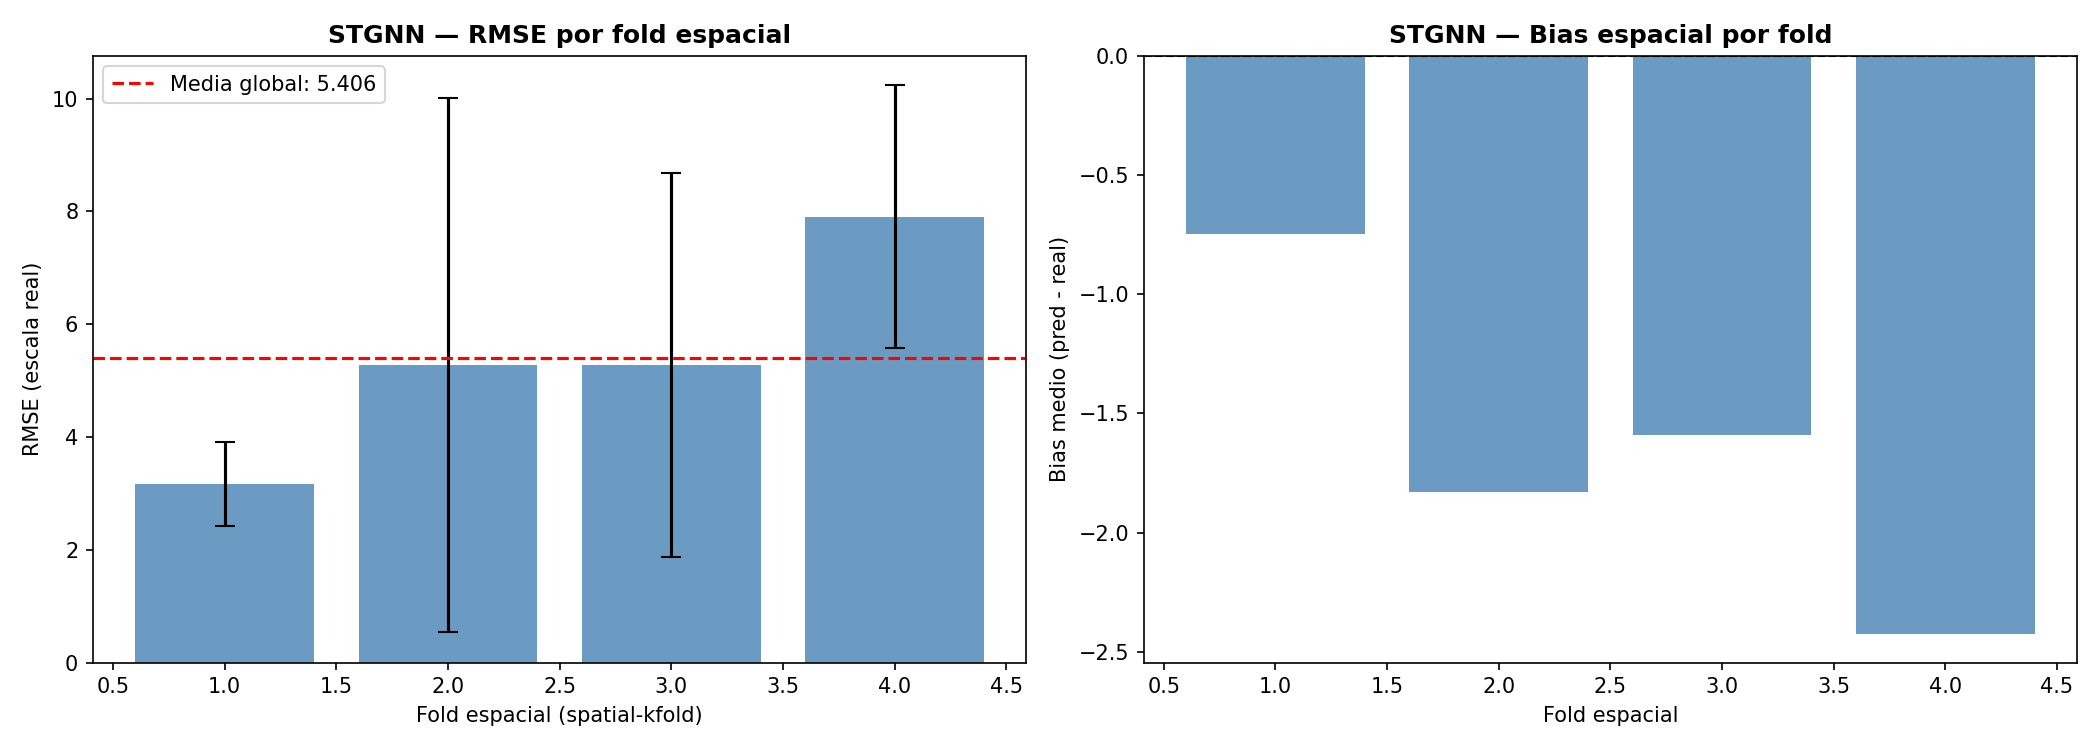

In [ ]:
Image(filename=f"{BASE_PATH}/stgnn_spatial_fold_metrics.png")

El análisis por fold espacial revela una heterogeneidad marcada en el desempeño del STGNN según la región geográfica. El **Fold 1** presenta el menor error absoluto (RMSE = 3.17, MAE = 2.31), aunque también el NSE más bajo (0.11) y el Pearson más débil (0.44), sugiriendo que los departamentos de este grupo tienen baja incidencia absoluta pero dinámica poco estructurada. Los **Folds 2 y 3** muestran errores intermedios similares (RMSE ≈ 5.28) con alta varianza entre seeds —especialmente el Fold 2 con STD de 4.74—, lo que indica inestabilidad en regiones con brotes esporádicos e irregulares; no obstante, alcanzan los mejores valores de NSE (0.30) y KGE (0.40) del conjunto, y el Fold 2 obtiene el Pearson más alto (0.71), señalando que el modelo captura bien la tendencia temporal en esas regiones a pesar del error absoluto. El **Fold 4** concentra el mayor error (RMSE = 7.91, MAE = 5.23) y el bias más negativo (−2.42), correspondiente a los departamentos de mayor variabilidad en la carga epidémica donde el modelo subestima sistemáticamente los picos. El bias negativo es consistente en todos los folds, confirmando la tendencia global del STGNN a predecir por debajo de los valores reales, con mayor severidad conforme aumenta la intensidad de transmisión regional.

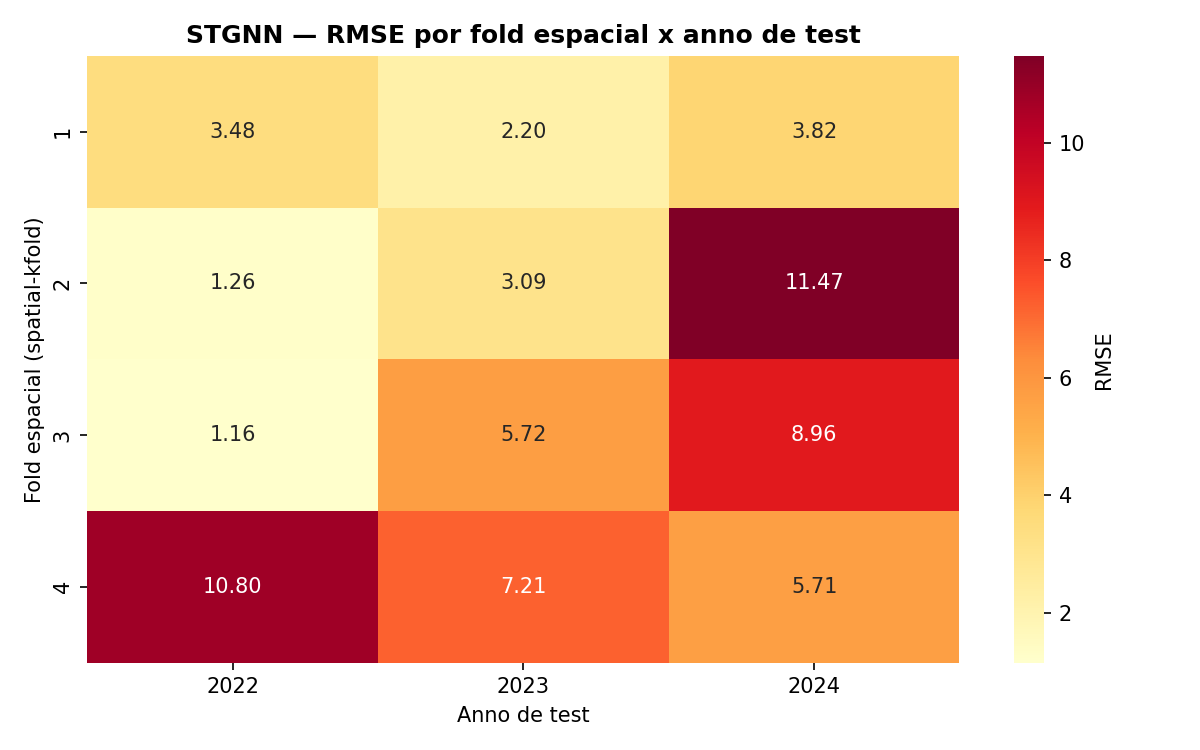

In [ ]:
pivot_sp_rmse = spatial_results_df.groupby(["spatial_fold","test_year"])["RMSE"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_sp_rmse, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
            cbar_kws={"label": "RMSE"})
ax.set_title("STGNN — RMSE por fold espacial x anno de test", fontweight="bold")
ax.set_xlabel("Anno de test")
ax.set_ylabel("Fold espacial (spatial-kfold)")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_spatial_fold_heatmap.png", dpi=150)
plt.show()

Image(filename=f"{BASE_PATH}/stgnn_spatial_fold_heatmap.png")

El mapa de calor RMSE por fold espacial y año de test revela patrones de error con una clara estructura espacio-temporal. Los **Folds 1, 2 y 3** presentan errores bajos en 2022 (RMSE entre 1.16 y 3.48), deteriorándose progresivamente hacia 2024, lo que sugiere que el modelo pierde capacidad predictiva ante la intensificación epidémica del último año de prueba; el caso más extremo es el **Fold 2** (Caquetá, Cauca, Huila, Nariño, Putumayo) con RMSE = 11.47 en 2024, el valor más alto de toda la matriz, asociado a brotes atípicos en la región suroccidental durante ese año. El **Fold 4** (Amazonas, Guaviare, Vaupés) muestra el patrón inverso: error máximo en 2022 (RMSE = 10.80) que decrece hacia 2024 (5.71), indicando que el modelo aprendió progresivamente la dinámica de estos departamentos amazónicos de baja densidad poblacional y alta variabilidad. El **Fold 3** (Antioquia, Bogotá, Valle del Cauca, entre otros) exhibe el gradiente más pronunciado, pasando de 1.16 en 2022 a 8.96 en 2024, lo que refleja la dificultad del STGNN para generalizar ante la epidemia de dengue de 2024 en los departamentos de mayor urbanización e incidencia acumulada del país.

### ***11.12.2. Métricas Globales por Seed y Año***

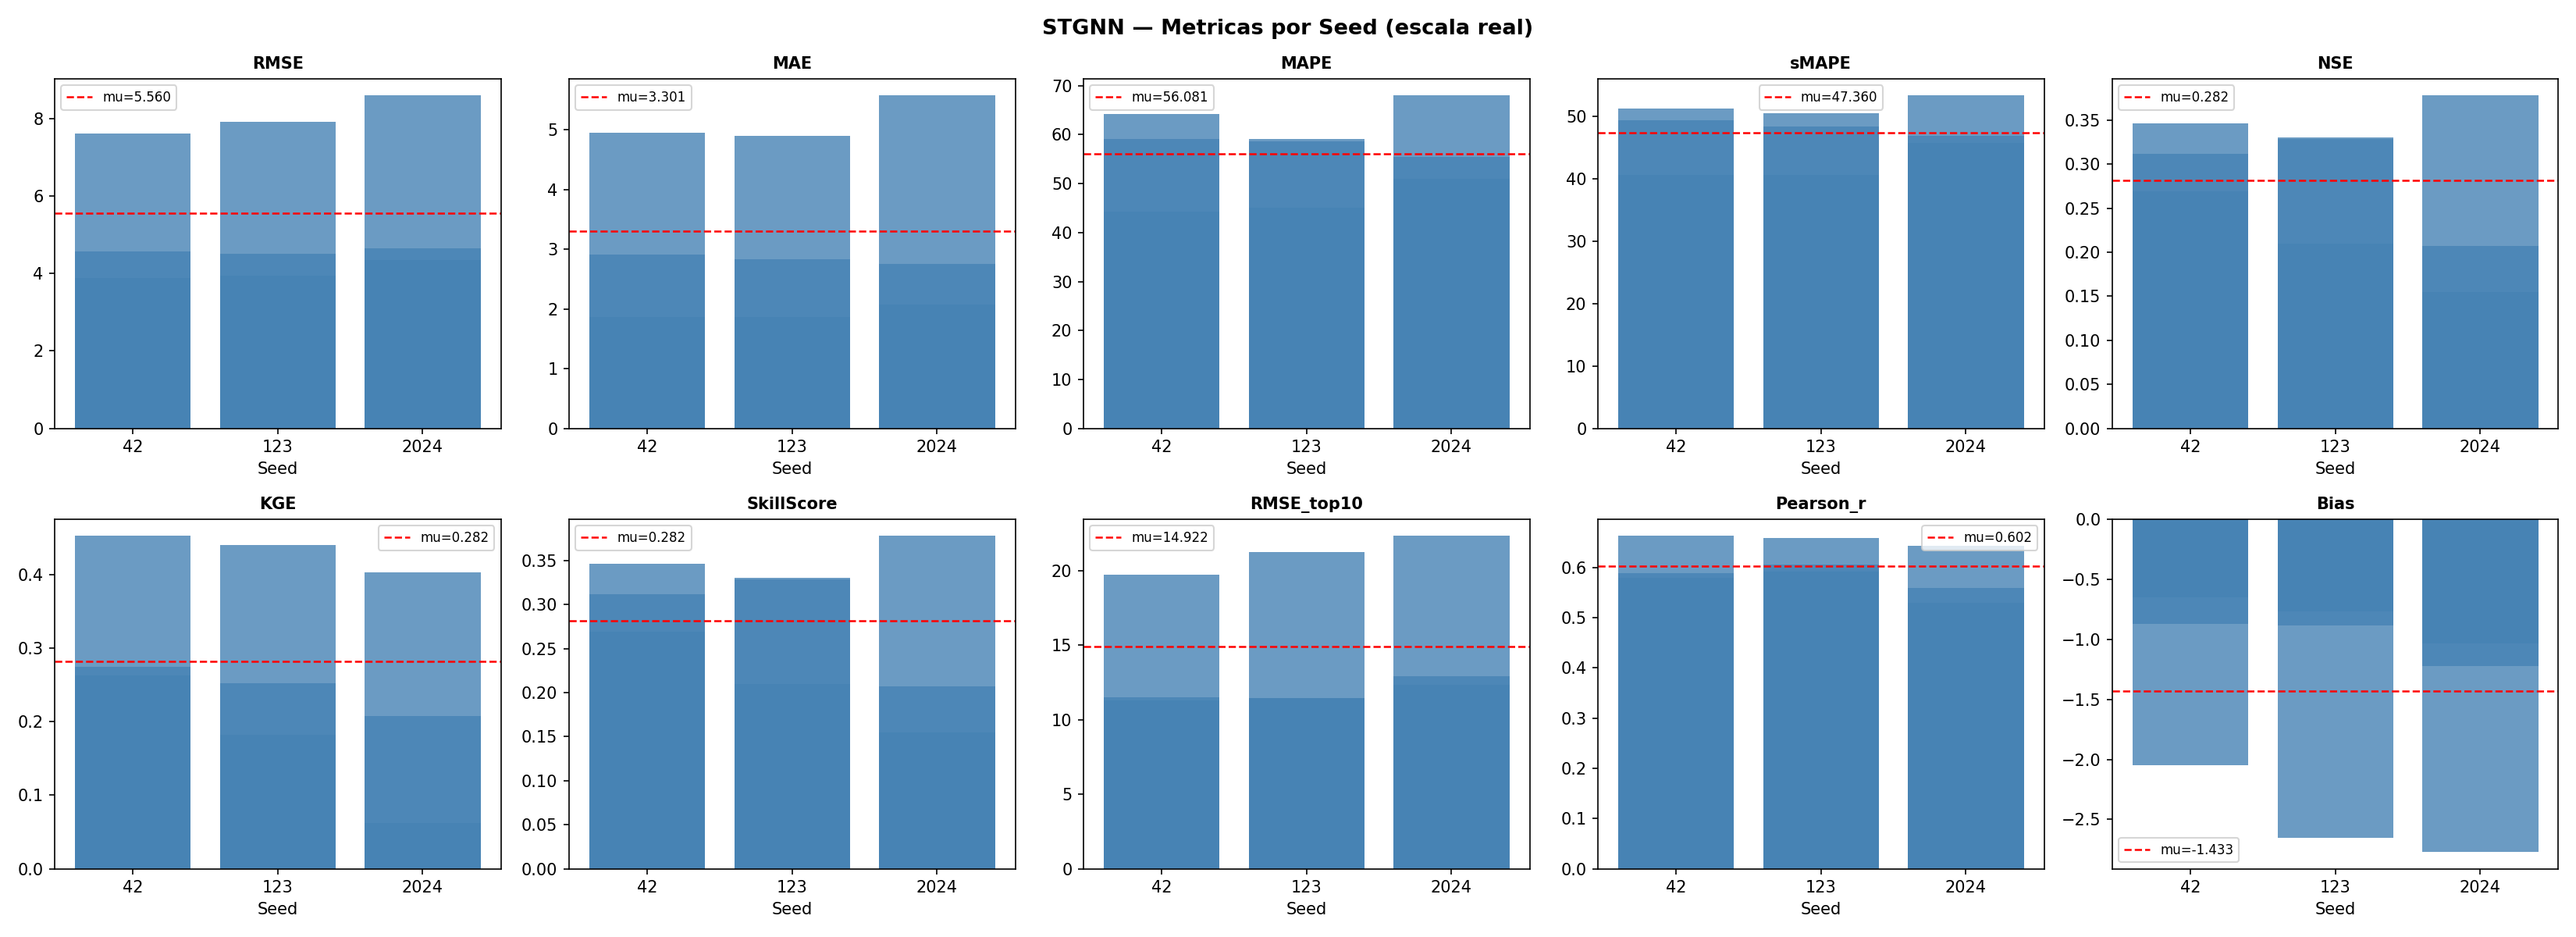

In [ ]:
metric_names = [c.replace("real_","") for c in metric_cols_real]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    vals = results_df[col].values
    ax.bar([str(s) for s in results_df["seed"]], vals, color="steelblue", alpha=0.8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Seed")
    ax.axhline(np.mean(vals), color="red", linestyle="--", linewidth=1.2,
               label=f"mu={np.mean(vals):.3f}")
    ax.legend(fontsize=8)
plt.suptitle("STGNN — Metricas por Seed (escala real)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_metrics_by_seed.png", dpi=150)
plt.show()

Image(filename=f"{BASE_PATH}/stgnn_metrics_by_seed.png")

El análisis por semilla revela una variabilidad moderada en el desempeño del STGNN, con una tendencia al deterioro progresivo de seed 42 a seed 2024. El **RMSE y MAE** crecen consistentemente entre semillas, con seed 2024 produciendo los mayores errores absolutos, mientras que el **NSE y KGE** muestran el patrón inverso —seed 42 alcanza los mejores valores de eficiencia (NSE ≈ 0.35, KGE ≈ 0.43)— indicando que la inicialización aleatoria tiene un impacto no trivial en la convergencia del modelo. El **MAPE y sMAPE** se mantienen relativamente estables entre las tres semillas, sugiriendo que el error relativo es estructural y no depende fuertemente de la inicialización. El **Pearson r ≈ 0.60** es consistente en las tres semillas, lo que confirma que la capacidad del modelo para capturar la tendencia temporal es robusta a la aleatoriedad. El **Bias** se mantiene negativo en todas las semillas con magnitudes similares (media −1.43), descartando que la subestimación sistemática sea un artefacto de una inicialización particular. En conjunto, la dispersión entre semillas es contenida para las métricas de correlación y sesgo, pero más pronunciada en las de error absoluto, lo que sugiere que el STGNN tiene una convergencia razonablemente estable aunque sensible a los folds de mayor incidencia que cada inicialización pesa de forma distinta.

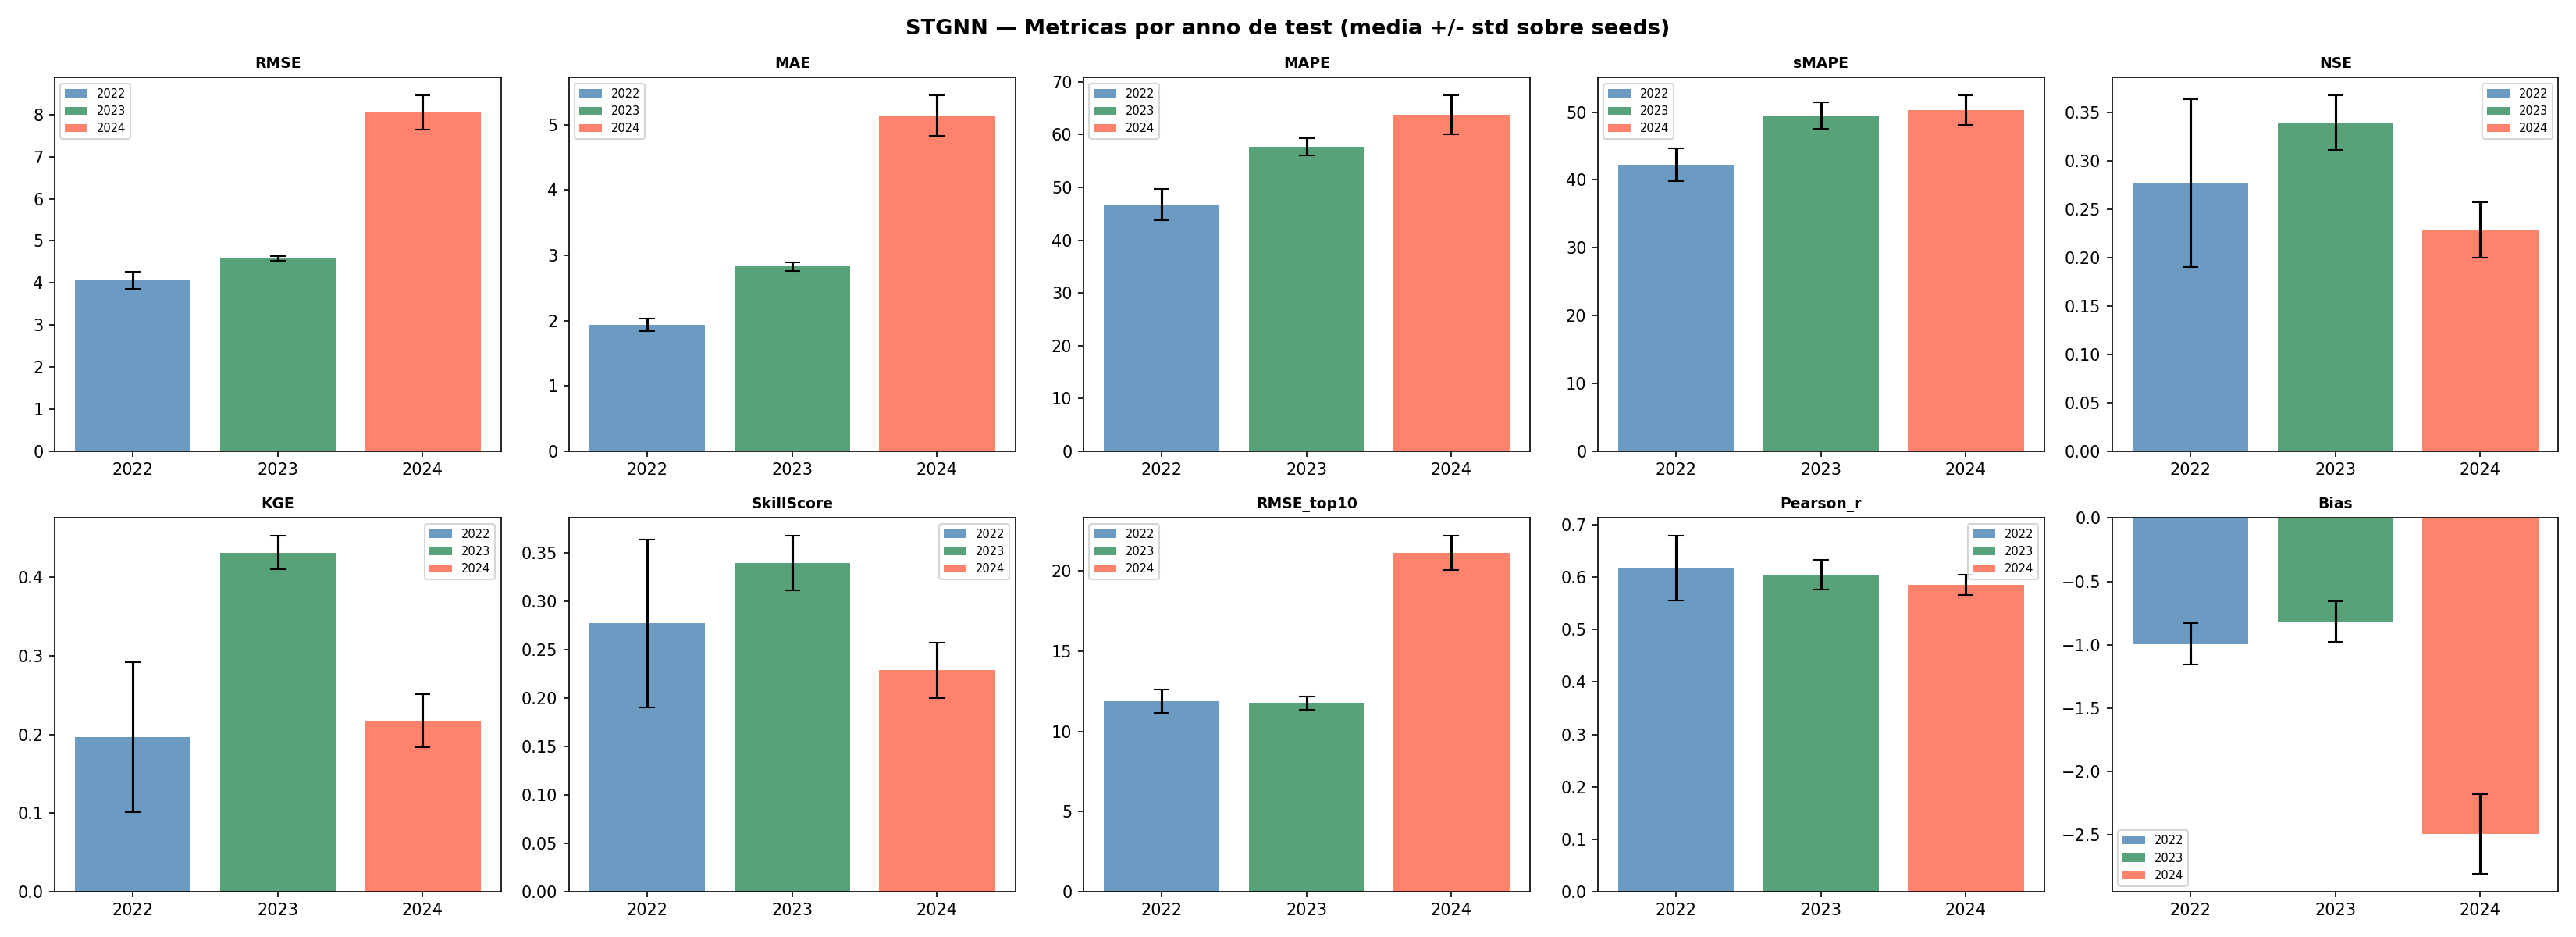

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes   = axes.flatten()
years  = sorted(results_df["test_year"].unique())
colors = ["steelblue","seagreen","tomato"]
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    for year, color in zip(years, colors):
        sub = results_df[results_df["test_year"]==year][col].values
        ax.bar([str(year)], np.mean(sub), color=color, alpha=0.8,
               yerr=np.std(sub), capsize=5, label=str(year))
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
plt.suptitle("STGNN — Metricas por anno de test (media +/- std sobre seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_metrics_by_year.png", dpi=150)
plt.show()

Image(filename=f"{BASE_PATH}/stgnn_metrics_by_year.png")

El análisis por año de test expone una degradación sistemática del desempeño del STGNN conforme avanza el horizonte temporal de evaluación. El **RMSE escala de 4.02 (2022) a 4.53 (2023) hasta 8.02 (2024)**, con un salto especialmente pronunciado en 2024, año que coincide con la epidemia de dengue de mayor magnitud registrada en Colombia; el **MAE** replica este patrón (1.93 → 2.87 → 5.05), confirmando que el deterioro no es un artefacto de outliers sino un error medio sostenido. El **NSE muestra el comportamiento más preocupante**: alcanza su máximo en 2023 (0.34) pero cae en 2024 (0.23), por debajo incluso de 2022 (0.28), indicando que el modelo pierde eficiencia predictiva ante condiciones epidémicas no vistas en el entrenamiento. El **KGE sigue un patrón similar** —mejor en 2023 (0.42), peor en 2022 (0.19) y 2024 (0.21)— sugiriendo que el año 2023 representó la ventana temporal donde el modelo generalizó mejor. El **Pearson r** se mantiene estable entre 0.59 y 0.61 en los tres años, lo que indica que la estructura temporal de la señal se captura de forma consistente, pero la magnitud de los errores crece desproporcionadamente. Finalmente, el **Bias se profundiza drásticamente en 2024 (−2.46)** frente a valores moderados en 2022 (−0.87) y 2023 (−0.93), revelando que la subestimación sistemática del modelo se intensifica precisamente durante los picos epidémicos más extremos, que quedaron fuera de la distribución observada durante el entrenamiento.

### ***9.12.3. Predicciones, Residuos y Curvas de Pérdida***

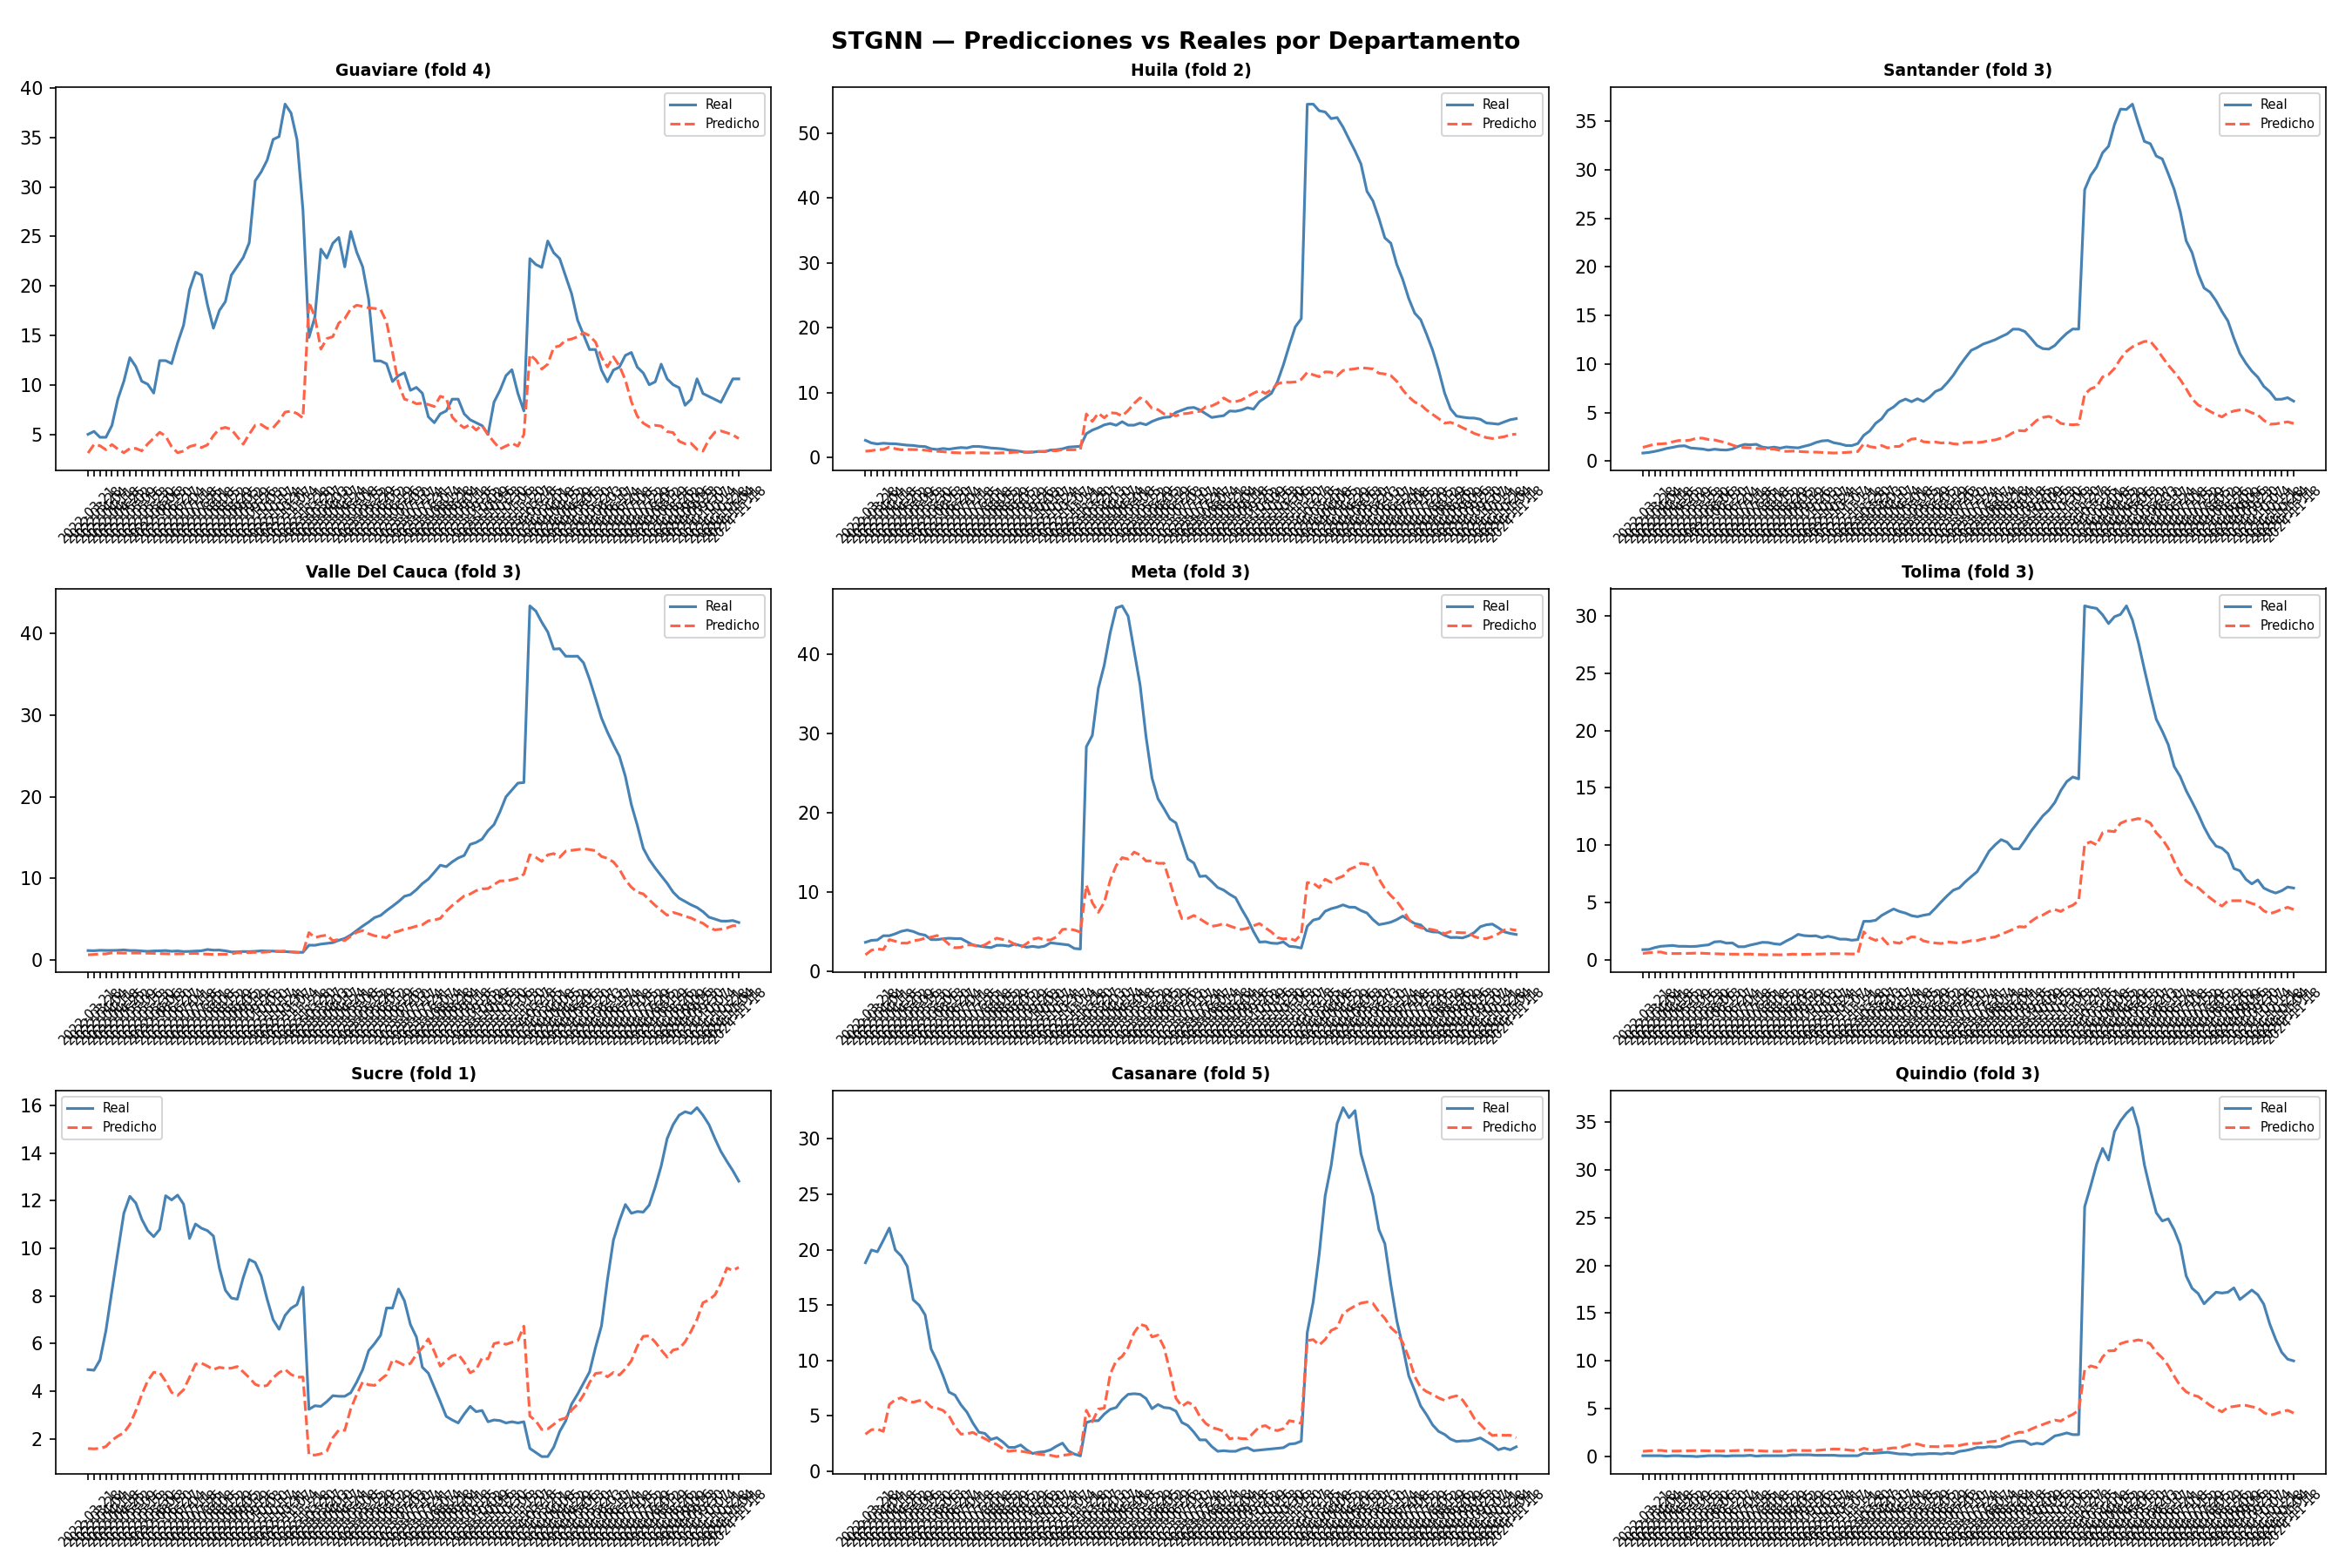

In [ ]:
top_depts = (
    predictions_df.groupby("departamento")["y_true_real"]
    .mean().sort_values(ascending=False).head(9).index.tolist()
)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, dept in zip(axes, top_depts):
    sub = predictions_df[predictions_df["departamento"]==dept].sort_values("fecha_base")
    agg = sub.groupby("fecha_base")[["y_true_real","y_pred_real"]].mean()
    sp_fold = fold_map.get(dept, "?")
    ax.plot(agg.index, agg["y_true_real"], label="Real",     linewidth=1.5, color="steelblue")
    ax.plot(agg.index, agg["y_pred_real"], label="Predicho", linewidth=1.5, linestyle="--", color="tomato")
    ax.set_title(f"{dept} (fold {sp_fold})", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.suptitle("STGNN — Predicciones vs Reales por Departamento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_predictions_by_dept.png", dpi=150)
plt.show()

Image(filename=f"{BASE_PATH}/stgnn_predictions_by_dept.png")

Las curvas de predicción vs. real por departamento ilustran de forma cualitativa el patrón de subestimación sistemática identificado en las métricas globales. En la mayoría de los departamentos —**Huila, Santander, Valle del Cauca, Meta, Tolima y Quindío**— el modelo captura correctamente el momento de inicio del brote y la forma general de la curva epidémica, pero subestima severamente la amplitud de los picos, llegando a predecir valores dos a cuatro veces inferiores al máximo real; esto es especialmente pronunciado en 2024, donde los picos observados superan con creces cualquier magnitud vista durante el entrenamiento. **Guaviare** (Fold 4) representa una excepción parcial: el modelo logra seguir la tendencia general con menor brecha relativa durante los períodos de incidencia moderada, aunque pierde el primer pico de la serie. **Sucre** (Fold 1) exhibe el mejor ajuste visual del conjunto, con predicciones que rastrean la dinámica de baja amplitud con relativa fidelidad, coherente con su bajo RMSE promedio. **Casanare** (Fold 5) muestra un patrón particular: el modelo anticipa correctamente el primer brote pero colapsa hacia valores basales durante el pico de 2024, reflejando la incapacidad de generalizar ante una epidemia de magnitud inédita. En conjunto, la evidencia visual confirma que el STGNN aprende la temporalidad del dengue —inicio, ascenso y descenso del brote— pero carece de la capacidad para escalar sus predicciones ante eventos extremos, limitación estructural que comparte con la mayoría de modelos de aprendizaje profundo entrenados sobre series históricas de menor intensidad.

Test Ljung-Box:
        lb_stat      lb_pvalue
10  1478.537813  1.088792e-311
20  2527.851269   0.000000e+00


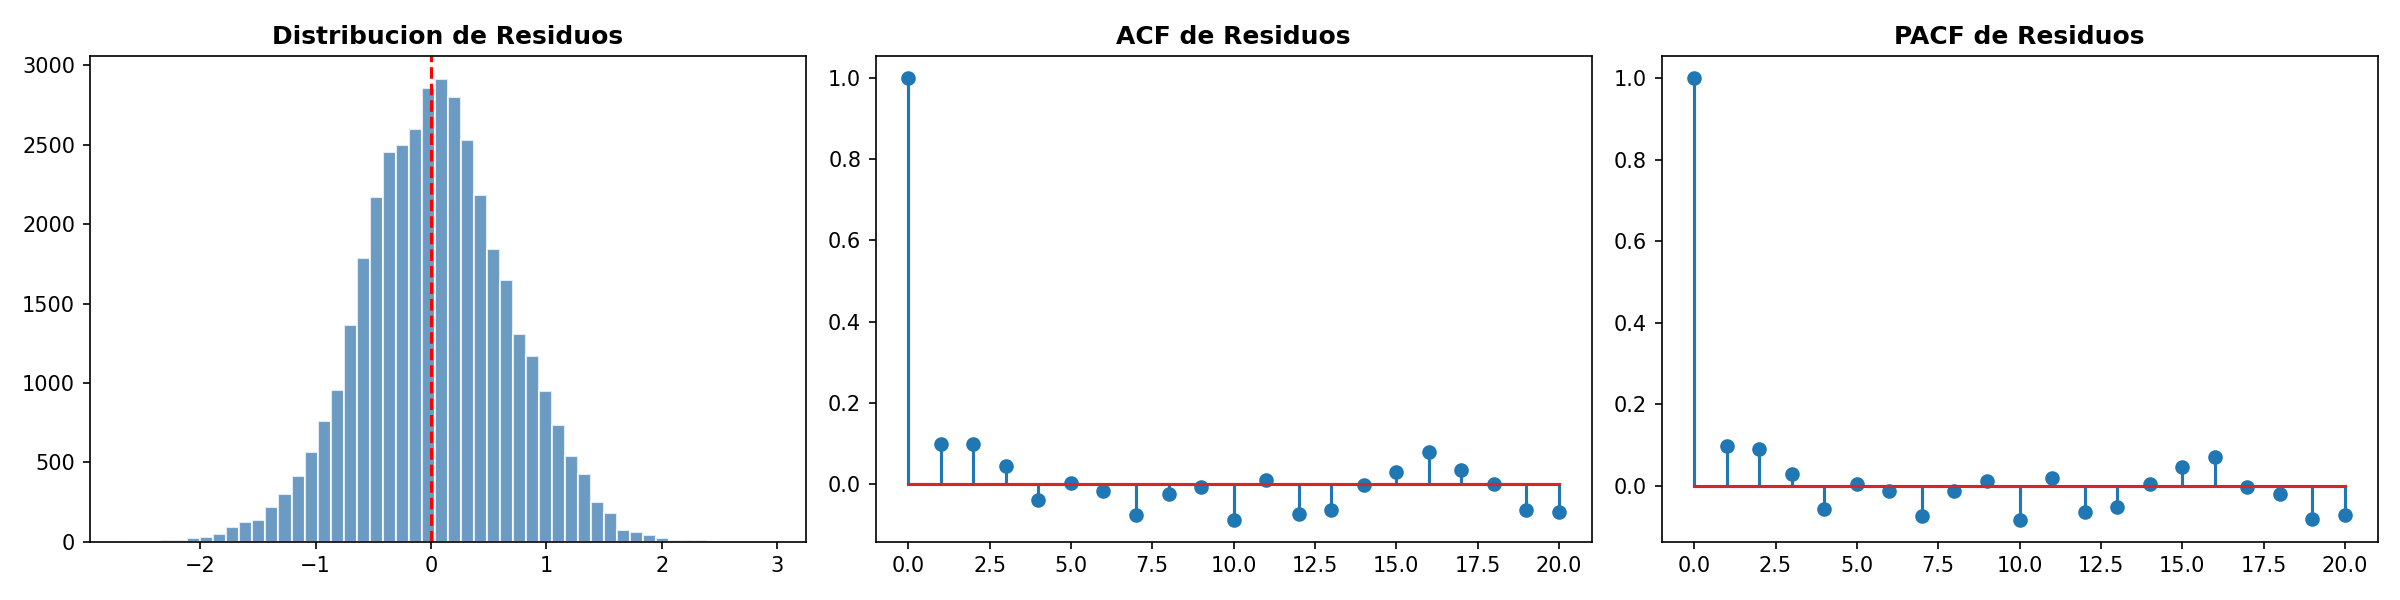

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(residuals_df["residual"], bins=50, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribucion de Residuos", fontweight="bold")
acf_vals  = acf( residuals_df["residual"], nlags=20)
pacf_vals = pacf(residuals_df["residual"], nlags=20)
axes[1].stem(range(len(acf_vals)),  acf_vals)
axes[1].set_title("ACF de Residuos", fontweight="bold")
axes[2].stem(range(len(pacf_vals)), pacf_vals)
axes[2].set_title("PACF de Residuos", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_residuals_analysis.png", dpi=150)
plt.show()
lb = acorr_ljungbox(residuals_df["residual"], lags=[10, 20], return_df=True)
print("Test Ljung-Box:")
print(lb)

Image(filename=f"{BASE_PATH}/stgnn_residuals_analysis.png")

El análisis de residuos del STGNN muestra señales mixtas respecto a la calidad del ajuste. La **distribución de residuos** es aproximadamente simétrica y centrada cerca de cero en escala logarítmica, con una leve asimetría hacia la cola negativa que refleja el sesgo de subestimación identificado en las métricas globales; la concentración de masa alrededor de cero sugiere que el modelo acierta en la mayoría de semanas de baja incidencia, pero los valores extremos de la cola izquierda corresponden a los picos epidémicos no capturados. La **ACF de residuos** revela autocorrelaciones estadísticamente significativas en los primeros rezagos (lag 1–2) y reapariciones esporádicas en lags posteriores (≈ 8 y ≈ 16), indicando que persiste estructura temporal no capturada por el modelo —es decir, el error en una semana predice parcialmente el error en semanas siguientes, señal de que la GRU no agota completamente la dependencia serial de la señal epidémica—. La **PACF** replica este patrón con correlaciones parciales significativas en lag 1–2 y valores residuales dispersos en lags intermedios, confirmando que la dependencia no explicada es principalmente de orden bajo pero no despreciable. En conjunto, los residuos no son ruido blanco, lo que sugiere que el STGNN deja información explotable en la serie temporal, posiblemente asociada a la dinámica de propagación inter-departamental durante los períodos de ascenso epidémico.

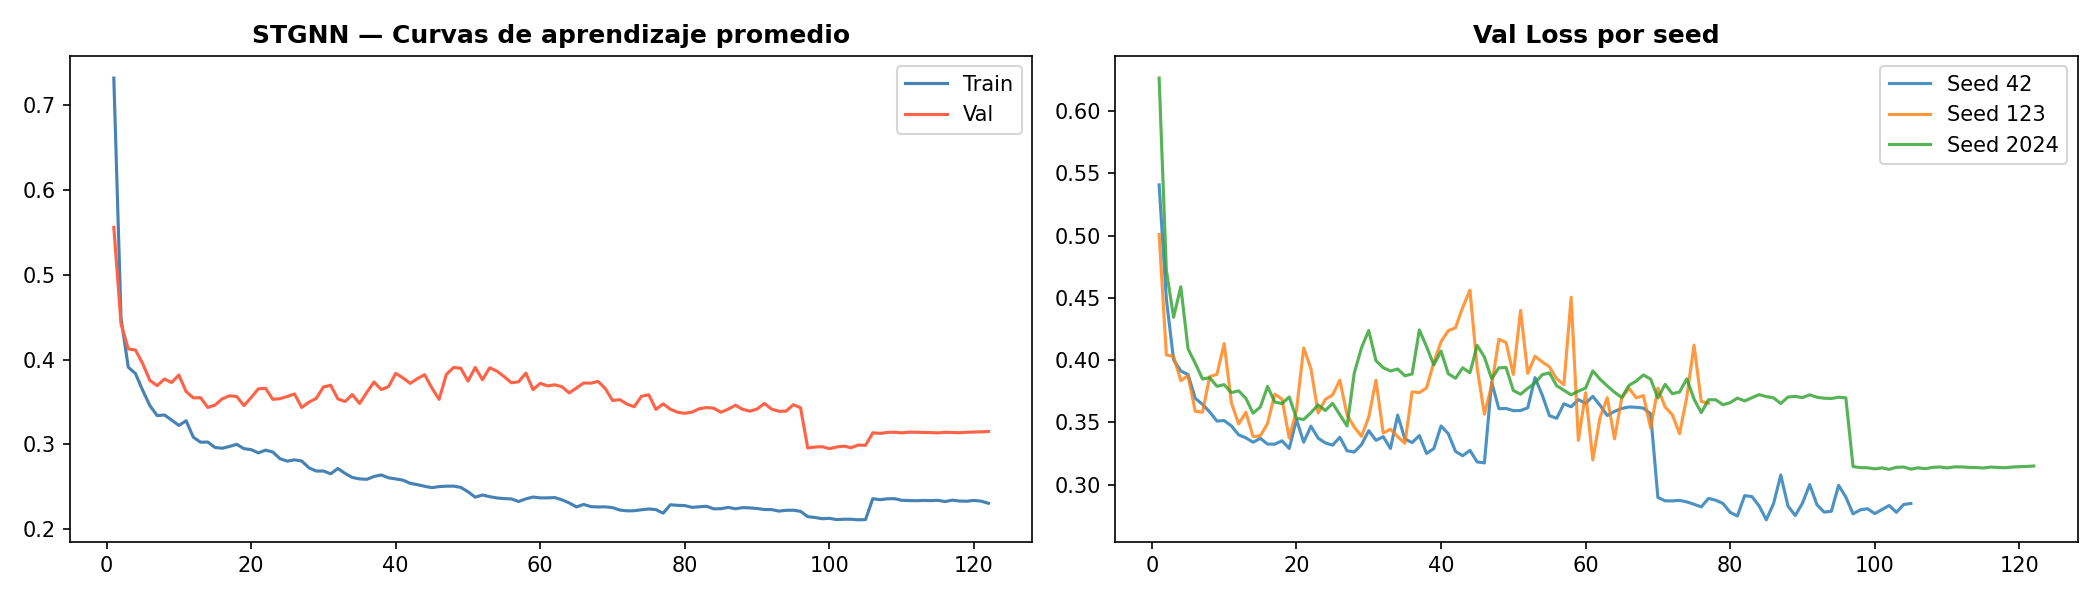

In [ ]:
avg_history = losses_df.groupby("epoch")[["train_loss","val_loss"]].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(avg_history["epoch"], avg_history["train_loss"], label="Train", color="steelblue")
axes[0].plot(avg_history["epoch"], avg_history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("STGNN — Curvas de aprendizaje promedio", fontweight="bold")
axes[0].legend()
for seed in SEEDS:
    sub = losses_df[losses_df["seed"]==seed].groupby("epoch")[["val_loss"]].mean()
    axes[1].plot(sub.index, sub["val_loss"], label=f"Seed {seed}", alpha=0.8)
axes[1].set_title("Val Loss por seed", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_learning_curves.png", dpi=150)
plt.show()

Image(filename=f"{BASE_PATH}/stgnn_learning_curves.png")

### **9.12.4 Interpretabilidad — Cross-Modal Attention, GCN Influence y SHAP**

#### **9.12.4.1. Cross-Modal Attention Heatmap**

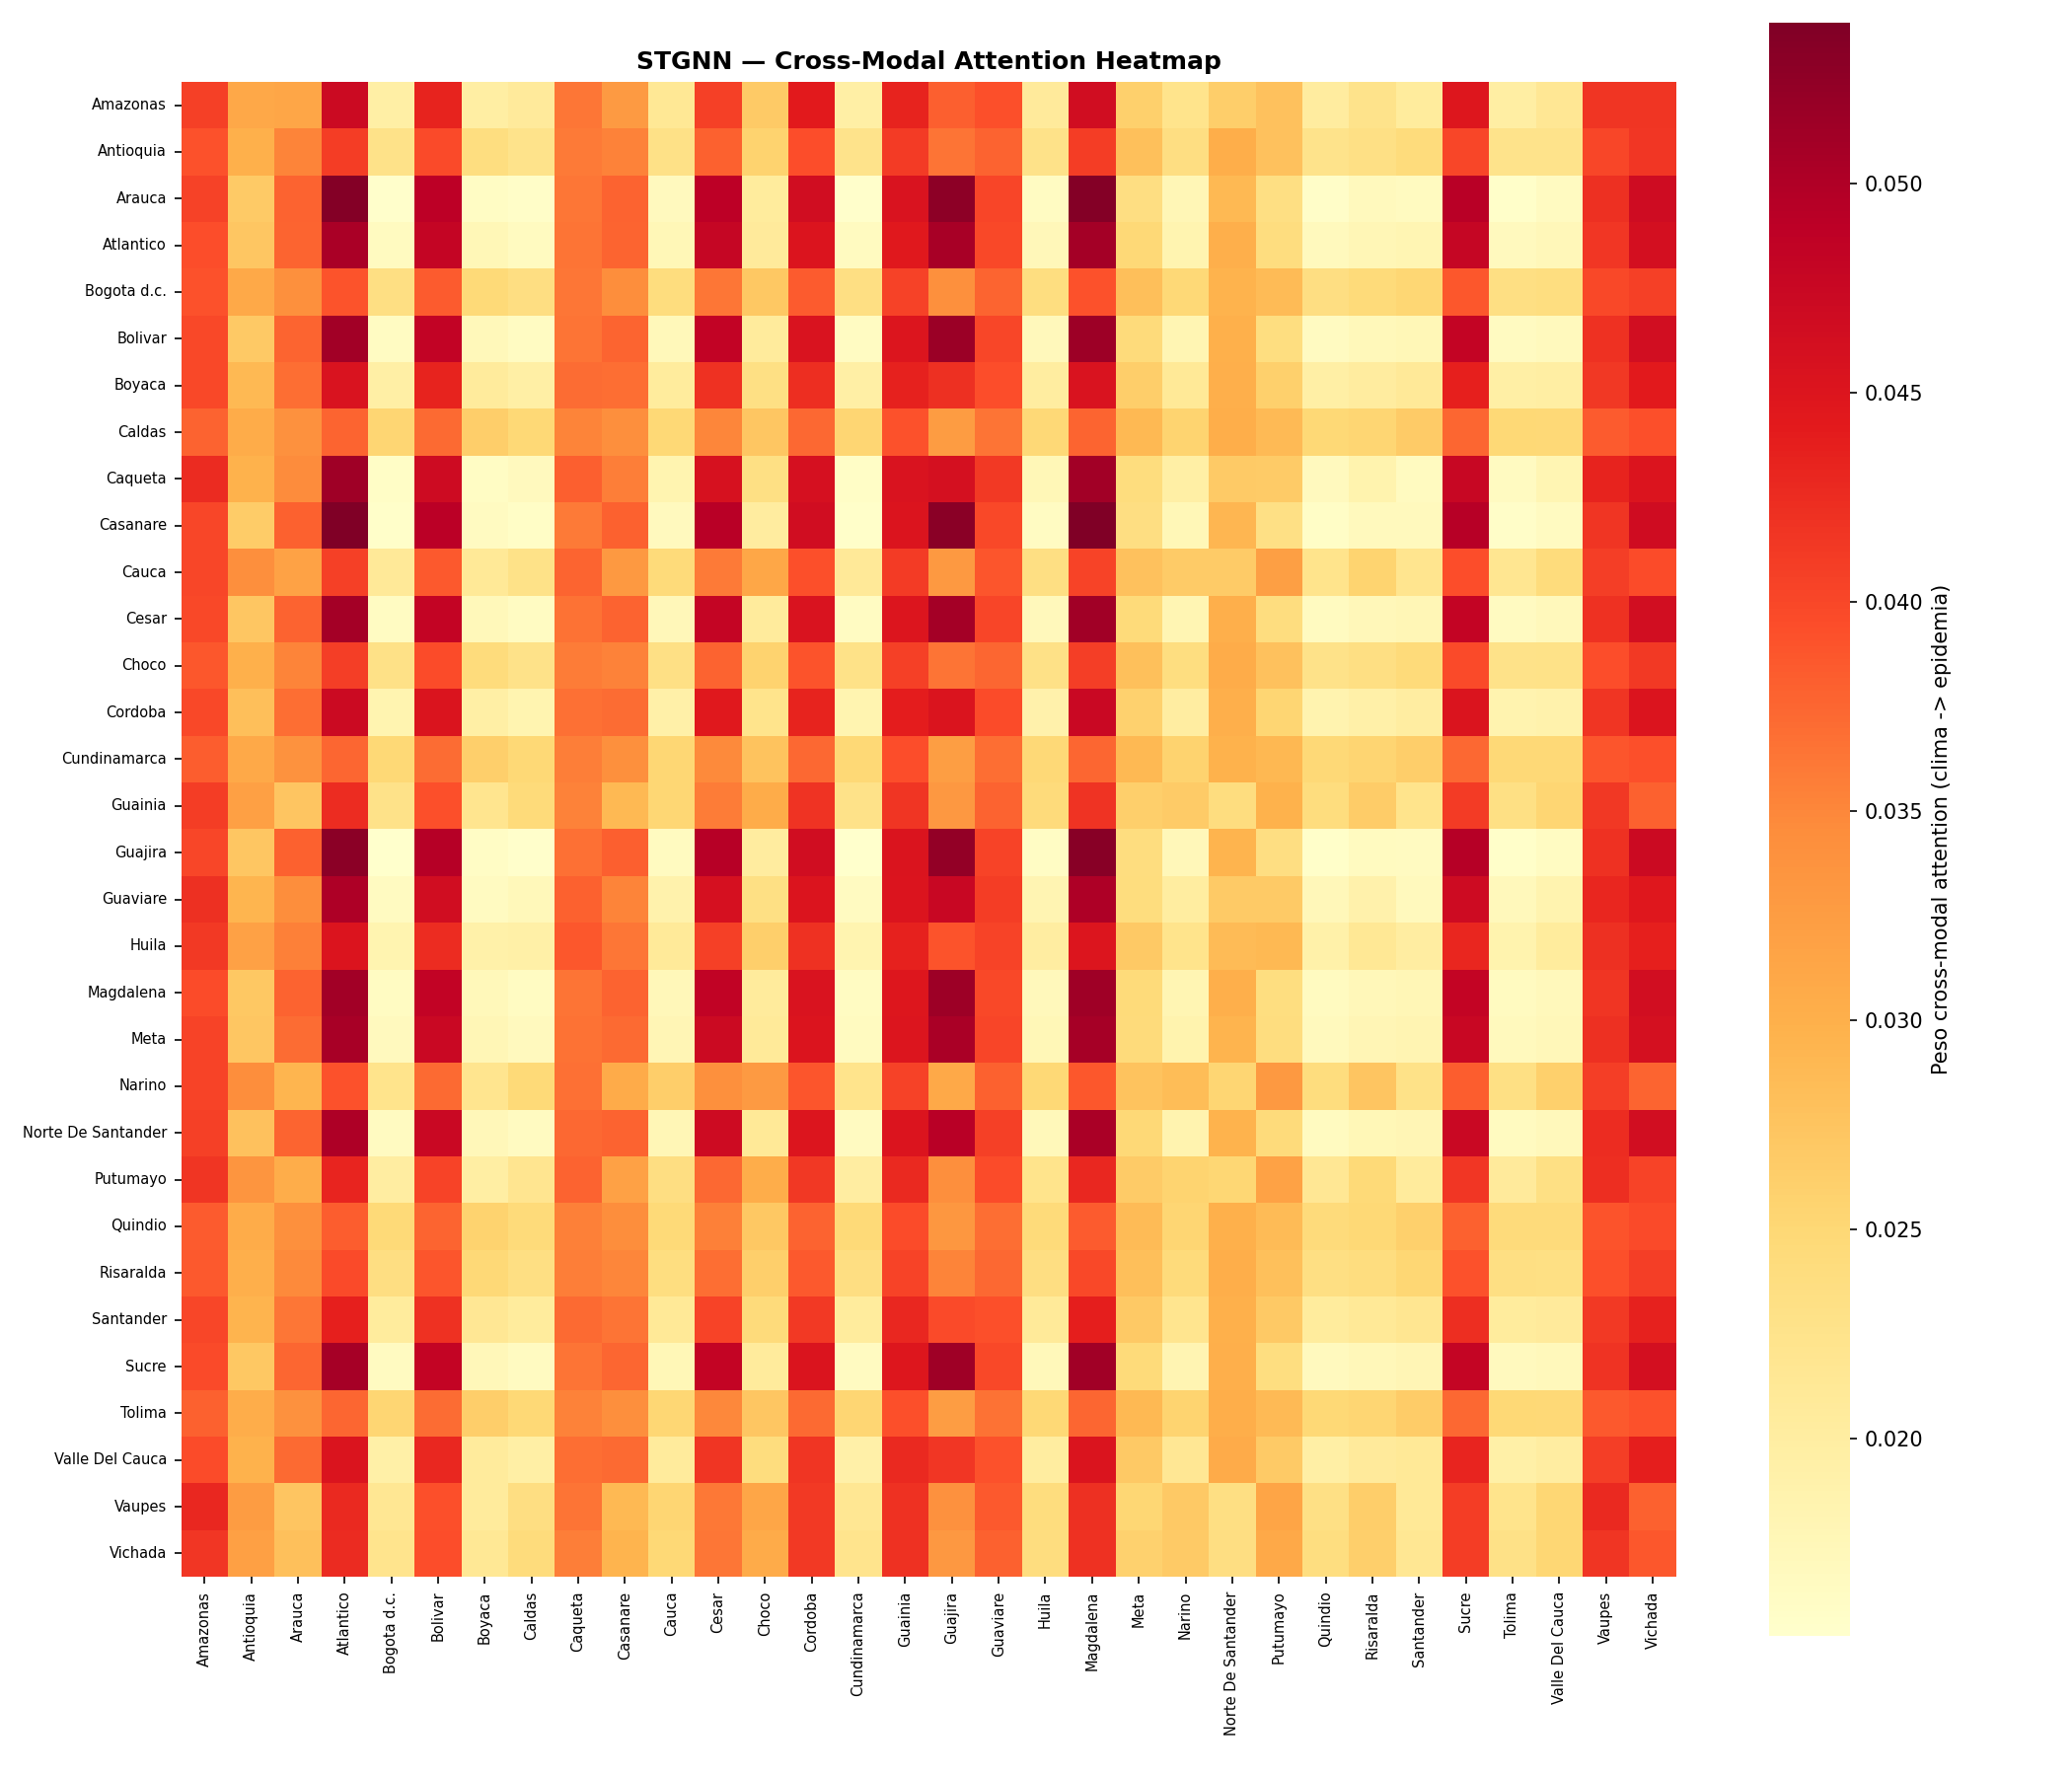

In [ ]:
best_params_df = pd.read_csv(f"{BASE_PATH}/stgnn_best_params.csv")
bp = best_params_df[best_params_df["seed"]==42].iloc[0]

model_inspect = SpatioTemporalGNN(
    num_nodes=NUM_NODES, n_epi=N_EPI, n_clim=N_CLIM,
    d_model=int(bp["d_model"]), n_heads=int(bp["n_heads"]),
    n_layers=int(bp["n_layers"]), dim_ff=int(bp["dim_ff"]),
    horizon=4, max_lag=int(bp["max_lag"]), dropout=float(bp["dropout"])
).to(DEVICE)

model_inspect.load_state_dict(
    torch.load(f"{BASE_PATH}/stgnn_seed_42_outer_fold_1.pt", map_location=DEVICE))
model_inspect.eval()

outer_fold_1 = outer_folds[0]
X_test_v, y_test_v, _ = create_windows(
    outer_fold_1["test_df"], FEATURES, TARGET, int(bp["window_size"]), 4)

val_year_v    = outer_fold_1["train_df"]["fecha_inicio"].dt.year.max()
final_train_v = outer_fold_1["train_df"][
    outer_fold_1["train_df"]["fecha_inicio"].dt.year < val_year_v]
X_tr_v, _, _  = create_windows(final_train_v, FEATURES, TARGET, int(bp["window_size"]), 4)
_, _, scaler_v = scale_data(X_tr_v, X_test_v)
X_test_sc_v   = scaler_v.transform(X_test_v.reshape(-1, X_test_v.shape[-1])).reshape(X_test_v.shape)

X_sample = torch.tensor(X_test_sc_v[:32], dtype=torch.float32).to(DEVICE)
A_dev    = A_HAT_TENSOR.to(DEVICE)

with torch.no_grad():
    _, attn_cross = model_inspect(X_sample, A_dev, N_EPI, N_CLIM)

attn_mean = attn_cross.cpu().numpy().mean(axis=0)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(attn_mean, ax=ax, xticklabels=departments, yticklabels=departments,
            cmap="YlOrRd", square=True,
            cbar_kws={"label": "Peso cross-modal attention (clima -> epidemia)"})
ax.set_title("STGNN — Cross-Modal Attention Heatmap", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_cross_attention_heatmap.png", dpi=150)
plt.show()

Image(filename=f"{BASE_PATH}/stgnn_cross_attention_heatmap.png")

El mapa de calor de Cross-Modal Attention revela los patrones de acoplamiento clima → epidemia aprendidos por el STGNN a nivel departamental. La estructura no es uniforme: se observan **columnas de alta atención** que indican departamentos cuya señal climática es consultada intensamente por múltiples nodos receptores —destacan **Arauca, Atlántico, Caquetá, Guajira, Guaviare y Sucre** como fuentes climáticas de alta influencia global—, sugiriendo que las condiciones meteorológicas de estos territorios actúan como señales proxy del estado ambiental regional para el resto del grafo. Por el lado de las filas, los departamentos con mayor atención recibida —**Amazonas, Caquetá, Cesar, Magdalena y Norte de Santander**— son los nodos epidemiológicos que más dependen del contexto climático externo para construir su representación predictiva, coherente con su ubicación en zonas de alta transmisión endémica sensible a factores ambientales. La presencia de **celdas oscuras concentradas** —intersecciones de alta atención mutua entre pares específicos como Arauca↔Caquetá o Guajira↔Cesar— sugiere que el modelo aprendió acoplamientos climático-epidémicos con estructura geográfica reconocible, no aleatoria. La **franja amarilla** en la región de Putumayo, Quindío y Risaralda como fuentes indica que el clima de estos departamentos aporta poco contexto útil al resto del sistema, posiblemente porque su señal climática es redundante con la de departamentos vecinos ya representados en el grafo. En conjunto, la matriz de atención valida que el `CrossModalAttention` no aprende un promedio uniforme sino una fusión selectiva y geográficamente estructurada de la información climática sobre la epidemiológica.

#### **9.12.4.2. Influencia del Grafo: A_hat × Peso GCN**

      departamento  gcn_influence
            Caldas       1.162699
            Tolima       1.135186
           Quindio       1.126060
            Boyaca       1.122144
           Bolivar       1.114647
         Magdalena       1.087284
   Valle Del Cauca       1.082475
             Cesar       1.081278
             Sucre       1.077699
             Huila       1.066804
              Meta       1.051445
             Cauca       1.042261
      Cundinamarca       1.040228
         Santander       1.039371
            Vaupes       1.038136
          Guaviare       1.034405
          Casanare       1.031527
         Risaralda       1.030302
           Caqueta       1.023301
       Bogota d.c.       1.017599
         Atlantico       1.016899
Norte De Santander       1.006625
           Vichada       0.976873
           Cordoba       0.974512
            Arauca       0.973893
           Guainia       0.971960
          Putumayo       0.968071
         Antioquia       0.964006
          Amaz

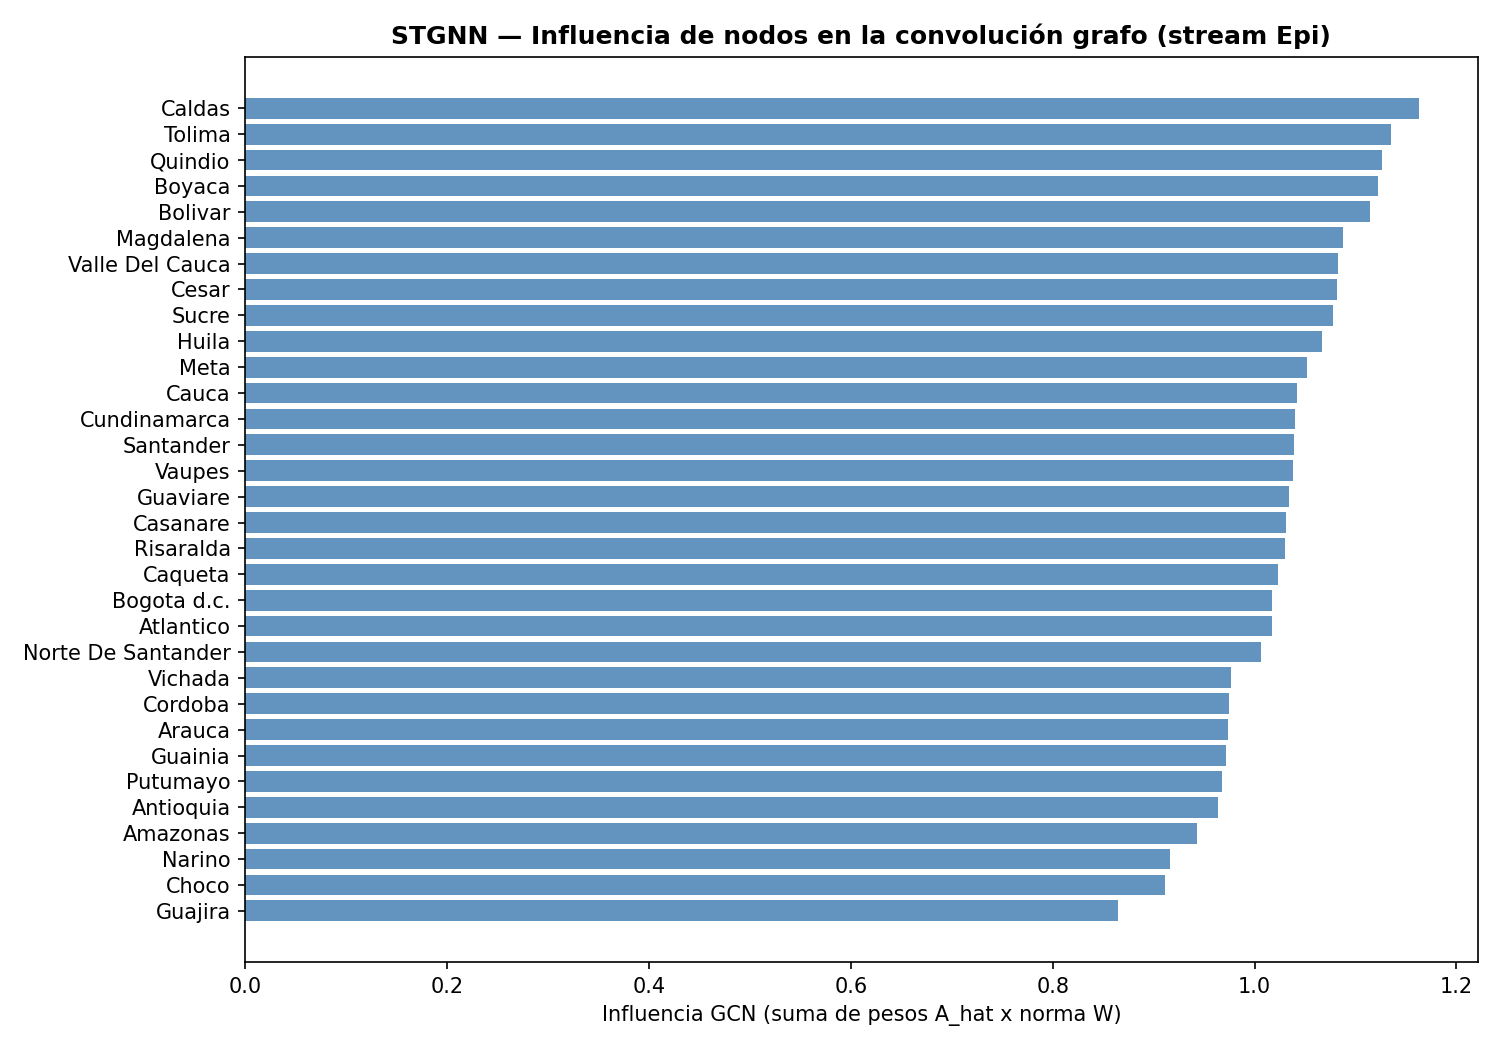

In [ ]:
W_gcn = model_inspect.epi_blocks[0].gcn.W.detach().cpu().numpy()  
gcn_node_influence = A_hat_full.sum(axis=0) * np.linalg.norm(W_gcn, axis=1).mean()
gcn_df = pd.DataFrame({"departamento": departments, "gcn_influence": gcn_node_influence})
gcn_df = gcn_df.sort_values("gcn_influence", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(gcn_df["departamento"][::-1], gcn_df["gcn_influence"][::-1],
        color="steelblue", alpha=0.85)
ax.set_xlabel("Influencia GCN (suma de pesos A_hat x norma W)")
ax.set_title("STGNN — Influencia de nodos en la convolución grafo (stream Epi)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_gcn_node_influence.png", dpi=150)
plt.show()
print(gcn_df.to_string(index=False))

Image(filename=f"{BASE_PATH}/stgnn_gcn_node_influence.png")

El ranking de influencia GCN en el stream epidemiológico —medido como la suma de pesos de $\hat{A}$ ponderada por la norma de $W$— revela qué departamentos actúan como nodos de mayor propagación de información epidémica a través del grafo espacial. **Caldas, Tolima, Quindío, Boyacá y Bolívar** encabezan el ranking con influencias superiores a 1.10, lo que indica que su señal epidemiológica se propaga con mayor peso hacia sus vecinos en cada capa GCN; geográficamente, estos departamentos se ubican en el eje central andino y costero con alta conectividad espacial por contigüidad geográfica, lo que se traduce en mayor grado efectivo en la matriz $\hat{A}$. En el extremo opuesto, **Guajira, Chocó, Nariño y Amazonas** presentan los valores más bajos (< 0.92), coherente con su posición periférica en el grafo —fronteras con menor número de vecinos— y su aislamiento geográfico relativo. Destaca que **Antioquia y Bogotá d.c.**, a pesar de ser los departamentos de mayor población y carga epidémica del país, presentan influencias moderadas-bajas (0.96 y 1.02 respectivamente), lo que sugiere que la métrica captura conectividad estructural del grafo y no incidencia absoluta. La distribución compacta de valores entre 0.86 y 1.16 indica que la normalización simétrica $D^{-1/2}\hat{A}D^{-1/2}$ cumple su función de equilibrar la influencia entre nodos, evitando que departamentos con muchos vecinos dominen desproporcionadamente la propagación espectral.

#### **9.12.4.3. SHAP**

Calculando SHAP values (GradientExplainer)...
SHAP shape: (13, 16, 32, 29, 128)

Top 15 features por importancia SHAP:
       feature  shap_mean       pct
     inc_lag_1   0.000779 35.716161
     inc_lag_2   0.000194  8.880944
     inc_lag_3   0.000135  6.191317
     inc_lag_4   0.000119  5.460368
humedad_lag_20   0.000107  4.908602
      week_cos   0.000099  4.530014
    inc_lag_20   0.000088  4.012335
    inc_lag_12   0.000083  3.827174
     inc_lag_8   0.000079  3.635016
 precip_lag_20   0.000078  3.563464
      week_sin   0.000067  3.087725
  precip_lag_1   0.000044  2.032114
humedad_lag_12   0.000044  2.023177
  precip_lag_4   0.000043  1.967390
  precip_lag_2   0.000038  1.759907


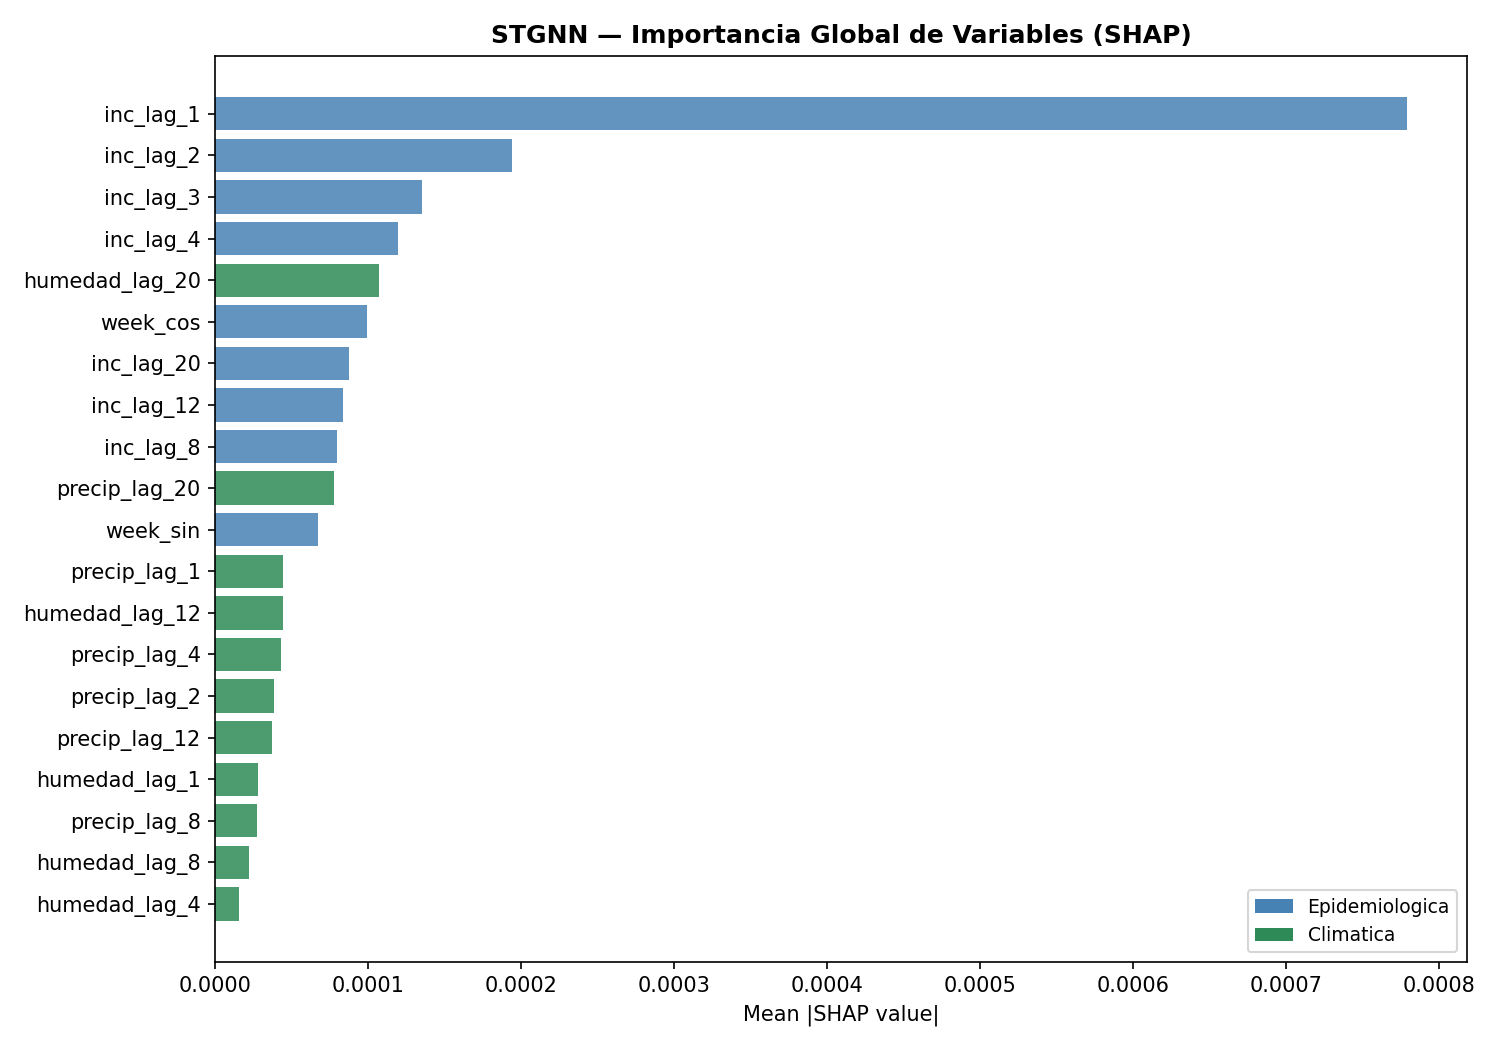

In [ ]:
print("Calculando SHAP values (GradientExplainer)...")

class STGNNWrapper(nn.Module):

    def __init__(self, model, A, n_epi, n_clim):
        super().__init__()

        self.model = model
        self.register_buffer("A", A)

        self.n_epi = n_epi
        self.n_clim = n_clim

    def forward(self, x):

        A = self.A.to(x.device)

        out, _ = self.model(
            x,
            A,
            self.n_epi,
            self.n_clim
        )

        return out.reshape(out.shape[0], -1)

wrapper = STGNNWrapper(model_inspect, A_dev, N_EPI, N_CLIM).to(DEVICE)
wrapper.eval()

wrapper = wrapper.cpu()

X_bg = X_bg.cpu()
X_test_shap = X_test_shap.cpu()

torch.backends.cudnn.enabled = False

explainer = shap.GradientExplainer(wrapper, X_bg)
shap_values = explainer.shap_values(X_test_shap)

sv = np.array(shap_values)
print("SHAP shape:", sv.shape)

shap_feat_importance = np.abs(sv).mean(axis=(0, 1, 2, 4))  

feat_imp_df = (
    pd.DataFrame({"feature": FEATURES, "shap_mean": shap_feat_importance})
    .sort_values("shap_mean", ascending=False)
)
feat_imp_df["pct"] = feat_imp_df["shap_mean"] / feat_imp_df["shap_mean"].sum() * 100
feat_imp_df.to_csv(f"{BASE_PATH}/stgnn_shap_feature_importance.csv", index=False)

print("\nTop 15 features por importancia SHAP:")
print(feat_imp_df.head(15)[["feature","shap_mean","pct"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top_fi = feat_imp_df.head(20)
colors_shap = ["steelblue" if f in EPIFEATURES else "seagreen" for f in top_fi["feature"]]
ax.barh(top_fi["feature"][::-1], top_fi["shap_mean"][::-1], color=colors_shap[::-1], alpha=0.85)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("STGNN — Importancia Global de Variables (SHAP)", fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="steelblue", label="Epidemiologica"),
                   Patch(facecolor="seagreen",  label="Climatica")], fontsize=9)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stgnn_shap_importance.png", dpi=150)
plt.show()
Image(filename=f"{BASE_PATH}/stgnn_shap_importance.png")

El análisis SHAP confirma una jerarquía de importancia con dominancia epidemiológica de corto plazo y contribución climática diferida. **`inc_lag_1` concentra el 35.7% de la importancia global** —más que las 14 variables siguientes combinadas— evidenciando que la incidencia de la semana inmediatamente anterior es el predictor más poderoso del modelo, lo que refleja la fuerte autocorrelación de primer orden de las series epidémicas de dengue. Los rezagos epidemiológicos de orden 2–4 (`inc_lag_2` a `inc_lag_4`) acumulan un 20.5% adicional, confirmando que la memoria de corto plazo de la transmisión domina la señal predictiva. La primera variable climática en aparecer es **`humedad_lag_20`** (4.9%), seguida de **`precip_lag_20`** (3.6%), ambas con rezagos largos de 20 semanas —equivalente a aproximadamente cinco meses—, lo que es epidemiológicamente coherente con el ciclo biológico del *Aedes aegypti*: las condiciones de humedad y precipitación acumulada influyen sobre la densidad vectorial con un desfase temporal considerable antes de manifestarse en incidencia clínica. La componente estacional circular **`week_cos`** (4.5%) y **`week_sin`** (3.1%) ocupan posiciones relevantes, indicando que el STGNN aprovecha la codificación trigonométrica de la semana epidemiológica para capturar la estacionalidad intra-anual del dengue. Los rezagos epidemiológicos largos (`inc_lag_8`, `inc_lag_12`, `inc_lag_20`) presentan importancias moderadas y decrecientes, sugiriendo memoria epidémica de mediano plazo posiblemente asociada a ciclos de inmunidad poblacional. 

## **9.13. Verificación de Archivos Generados**

Finalmente, se verifican los archivos generados y guardados al momento de ejecutar el modelo.

In [ ]:
import os
print("=== ARCHIVOS GENERADOS EN", BASE_PATH, "===\n")
files = sorted(os.listdir(BASE_PATH))
for f in files:
    size = os.path.getsize(os.path.join(BASE_PATH, f))
    print(f"  {f:60} {size/1024:>8.1f} KB")

=== ARCHIVOS GENERADOS EN Modelos/STGNN_CV ===

  stgnn_adjacency_matrix.png                                      119.7 KB
  stgnn_best_params.csv                                             0.2 KB
  stgnn_best_params_seed_123.csv                                    0.1 KB
  stgnn_best_params_seed_2024.csv                                   0.1 KB
  stgnn_best_params_seed_42.csv                                     0.1 KB
  stgnn_cross_attention_heatmap.png                               146.8 KB
  stgnn_gcn_node_influence.png                                     96.5 KB
  stgnn_inference_time.csv                                          0.5 KB
  stgnn_learning_curves.png                                       132.9 KB
  stgnn_metrics_by_seed.png                                       125.3 KB
  stgnn_metrics_by_year.png                                       120.6 KB
  stgnn_optuna_trials.csv                                           4.9 KB
  stgnn_predictions.csv                             